# NOTEBOOK EDA

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import f_oneway

import os
import re

from IPython.display import display, Markdown

import missingno as msno
import sys

from rapidfuzz import process, fuzz

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from itertools import product

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"..\00_Data\00_Processed\df_eda.csv")

In [3]:
def convert_to_datetime(df):
    date_regex = r'^(?:(?:\d{4}[-/]\d{1,2}[-/]\d{1,2})|(?:\d{1,2}[-/]\d{1,2}[-/]\d{2,4}))(?:[\sT]+(?:[01]?\d|2[0-3]):[0-5]\d(?::[0-5]\d)?)?$'

    for col in df.columns:
        if df[col].dtype.name == 'object':
            mask = df[col].dropna().str.match(date_regex)
            if mask.all():
                df[col] = pd.to_datetime(df[col], errors='coerce', infer_datetime_format=True)

    return df

In [4]:
def convert_categorical(df):
    age_order = ['less than 25', '25-45', '46-65', 'greater than 65']
    score_order = ['low', 'medium', 'high']
    charge_degree_order = ["misdemeanor", "felony"]


    df["age_cat"] = pd.Categorical(df["age_cat"], categories= age_order, ordered=True)
    df["score_text"] = pd.Categorical(df["score_text"], categories= score_order, ordered=True)
    df["c_charge_degree"] = pd.Categorical(df["c_charge_degree"], categories= charge_degree_order, ordered=True)
    #df['days_in_jail_cat'] = pd.qcut(df['days_in_jail'], q=5, labels=['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto'])

    return df

In [5]:
df.columns

Index(['sex', 'race', 'age_cat', 'decile_score', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'score_text', 'screening_date', 'two_year_recid',
       'priors_count', 'c_charge_degree', 'start', 'end', 'event',
       'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'person_id',
       'agency_text', 'maritalstatus', 'language', 'rawscore', 'age',
       'juv_priors_count', 'adult_priors_count'],
      dtype='object')

In [6]:
df["score_text"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [7]:
df = convert_to_datetime(df)

In [8]:
df = convert_categorical(df)

## Guión


### -Sacar gráficos
    - Estadísticos descriptivos de las variables
    - .corr de scores y demográficas
    - is_recid y is_v_recid con demográficas
    - cantidad de falsos positivos y falsos negativos + porcentaje de acierto del score
    - Tablas de contigencias de variables demográficas sobre is_recid y v_is_recid y score intervalos

In [9]:
# En bar plot (plotly), animation_frame para la barra interactuable
def eda(df):
    lista_variables_numericas = df.select_dtypes(include = "number").columns.tolist()
    lista_variables_numericas.remove("person_id")
    lista_variables_categoricas = df.select_dtypes(include = ["object", "category"]).columns.tolist()
    lista_variables_temporales = df.select_dtypes(include = "datetime").columns.tolist()
    lista_booleanos = df[["is_recid", "is_violent_recid"]].columns.tolist()
    lista_chi2 = lista_variables_categoricas + lista_booleanos
    
    display(Markdown("# Análisis univariable"))

    for col in lista_variables_categoricas:
    # Sacamos valores únicos y sus conteos
        counts = df[col].value_counts(dropna=False)
        
        if df[col].nunique() <= 3:
            # Preparamos labels con nombre + conteo
            labels = [f'{valor}\n{count}' for valor, count in zip(counts.index, counts.values)]
            
            # Dibujamos el pie chart
            plt.figure()
            plt.pie(
                counts.values,
                labels=labels,
                autopct='%1.1f%%'
            )
            
            plt.title(f'Distribución de {col}')
            plt.show()

        else:
            total = counts.sum()

            df_count = counts.reset_index()
            df_count.columns = [col, "frecuencia"]
            df_count["pct"] = df_count["frecuencia"] / total

            fig = px.bar(
                df_count,
                x=col,
                y='frecuencia',
                text= df_count.apply(
                lambda r: f"{r['pct']:.1%}",
                axis=1
            ),
            )

            fig.update_layout(
            title=f'Número de personas por {col}',
            yaxis_title='Número de personas'
            )

            fig.show()


    # df["ethnic_code_text"].value_counts().plot(kind="bar")
    # plt.title('Distribucion de personas por raza')
    # plt.show()

    
    print(f"Media:\n{df[lista_variables_numericas].mean()}")
    print("\n")
    print(f"Mediana:\n{df[lista_variables_numericas].median()}")
    print("\n")
    print(f"Mínimo:\n{df[lista_variables_numericas].min()}")
    print("\n")
    print(f"Máximo:\n{df[lista_variables_numericas].max()}")
    print("\n")
    print(f"Varianza:\n{df[lista_variables_numericas].var()}")
    print("\n")
    print(f"Desviación típica:\n{df[lista_variables_numericas].std()}")
    print("\n")
    print(f"Moda:\n{df[lista_variables_numericas].mode()}")

    for col in lista_variables_numericas:
        df[[col]].boxplot(figsize=(8,5))
        plt.title(f"Distribución general de {col}")
        plt.show()
        print("\n")

    display(Markdown("# Análisis bivariable"))
    print("\n")

    for col_num in lista_variables_numericas:
        for col_cat in lista_variables_categoricas:
            if col_cat != "sex":
                sns.boxplot(
                    data= df,
                    x=col_cat,
                    y= col_num,
                    hue="sex"
                )
                plt.title(f"Distribución de {col_num} por género y {col_cat}")
                plt.show()
                print("\n")

    # for col_num1 in lista_variables_numericas:
    #     for col_num2 in lista_variables_numericas:
    #         if col_num1 != col_num2:
    #             sns.relplot(
    #                 data= df,
    #                 x=col_num2,
    #                 y= col_num1,
                    
    #             )
    #             plt.title(f"Distribución de {col_num2} por {col_num1}")
    #             plt.show()
    #             print("\n")



    corr_matrix = df[lista_variables_numericas].corr(method= "spearman")

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        center=0
    )

    plt.title("Matriz de correlación")
    plt.show()

    

 
    # for var in lista_variables_numericas:
    #     sns.lineplot(
    #         data=df,
    #         x="Año",
    #         y=var,
    #         hue="sex",
    #         marker="o"
    #     )
    #     plt.title(f"Evolución temporal de {var}")
    #     plt.xticks(df["Año"].unique())
    #     plt.show()
    #     print("\n")

    for col1, col2 in combinations(lista_chi2, 2):
        tabla = pd.crosstab(df[col1], df[col2], margins= True)
        chi2, p, dof, expected = chi2_contingency(tabla)
        if(p <= 0.05):
            print(f"\nCrosstab entre {col1} y {col2}")
            display(tabla)


In [10]:
# df = df.set_index("person_id")

# Análisis univariable

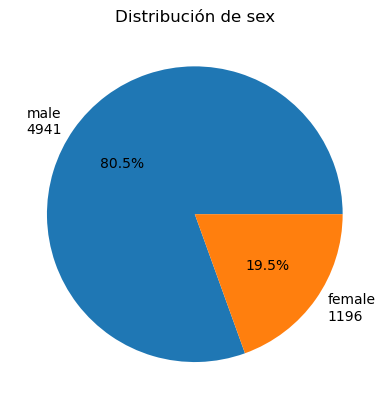

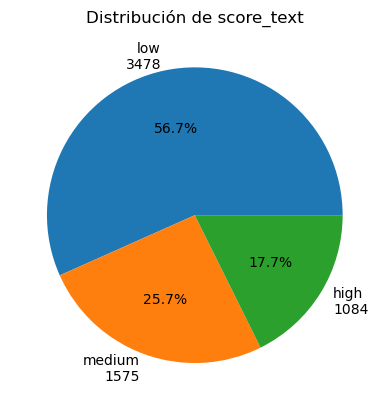

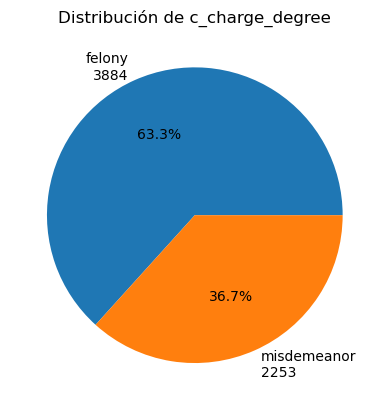

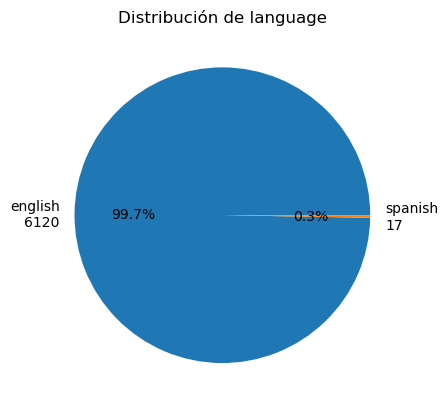

Media:
decile_score            4.334528
v_decile_score          3.587258
is_recid                0.397100
is_violent_recid        0.095812
two_year_recid          0.361577
priors_count            3.217859
start                  11.876324
end                   612.888056
event                   0.314486
juv_fel_count           0.058824
juv_misd_count          0.086524
juv_other_count         0.101515
rawscore               -2.412920
age                    32.570311
juv_priors_count        0.246863
adult_priors_count      3.007170
dtype: float64


Mediana:
decile_score            4.00
v_decile_score          3.00
is_recid                0.00
is_violent_recid        0.00
two_year_recid          0.00
priors_count            1.00
start                   0.00
end                   750.00
event                   0.00
juv_fel_count           0.00
juv_misd_count          0.00
juv_other_count         0.00
rawscore               -2.38
age                    29.00
juv_priors_count        0.00
adul

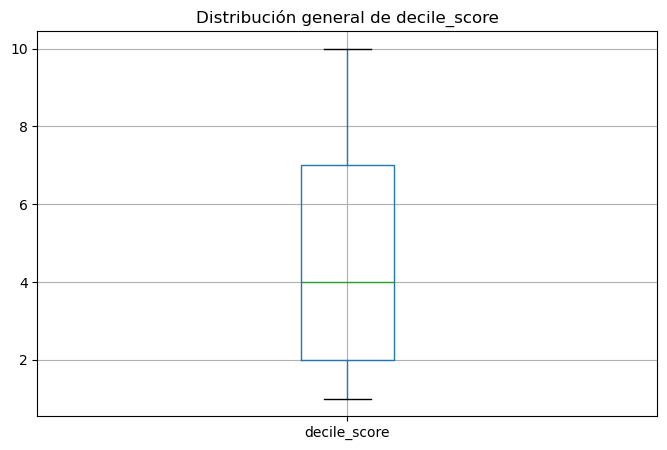

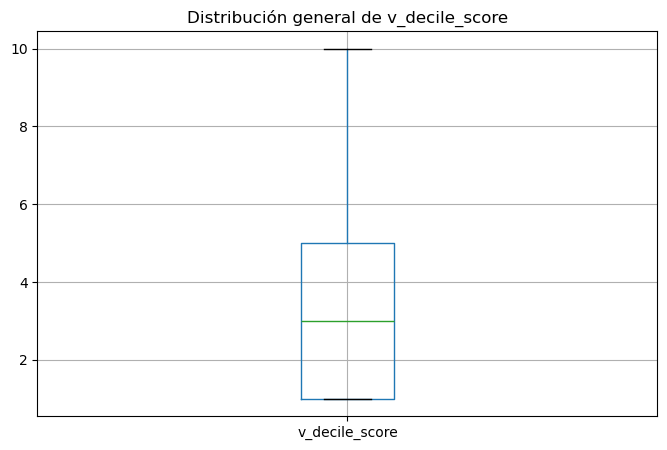

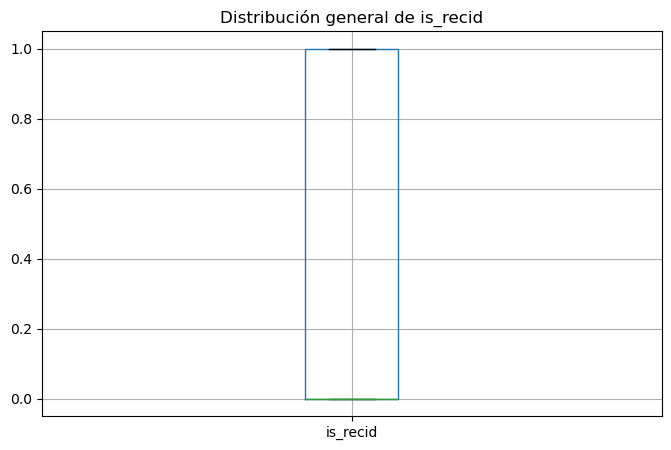

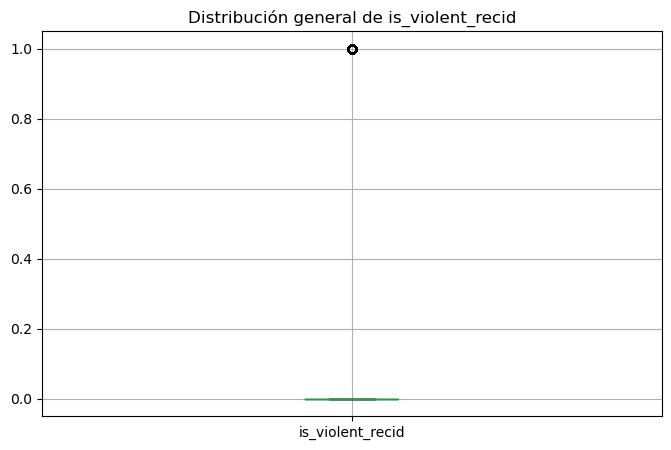

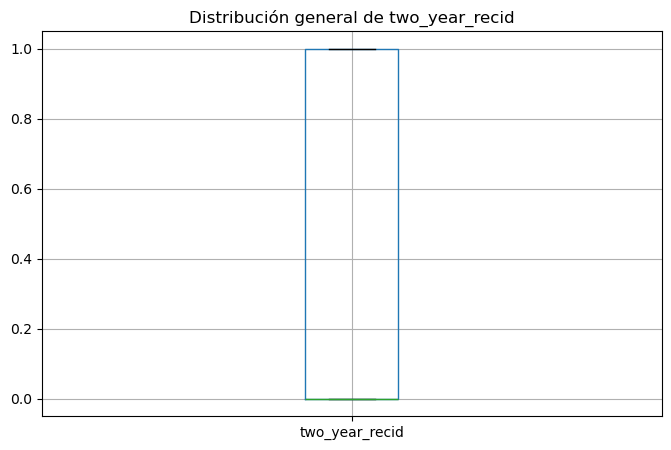

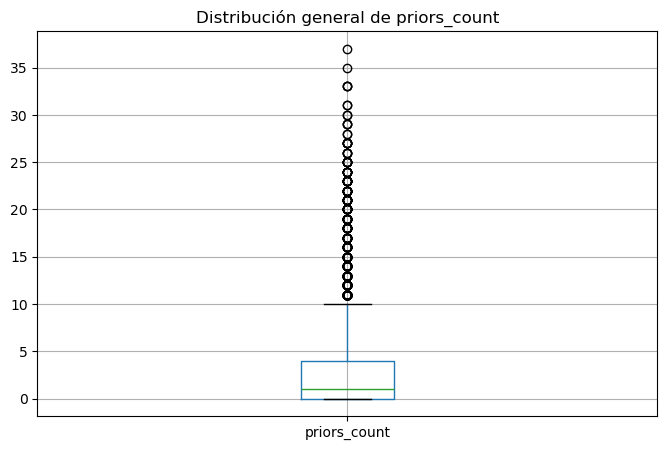

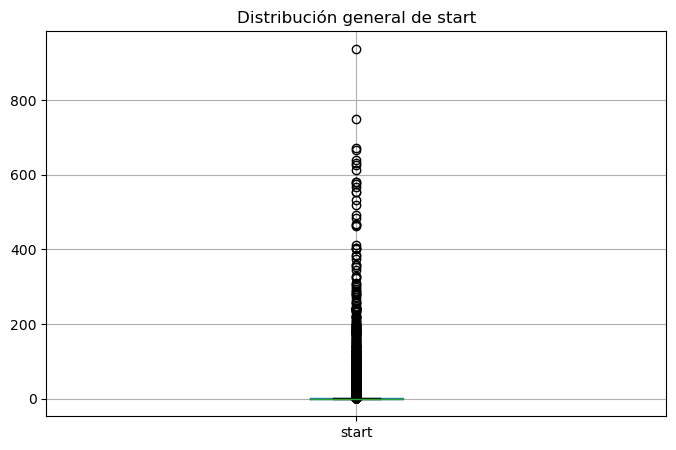

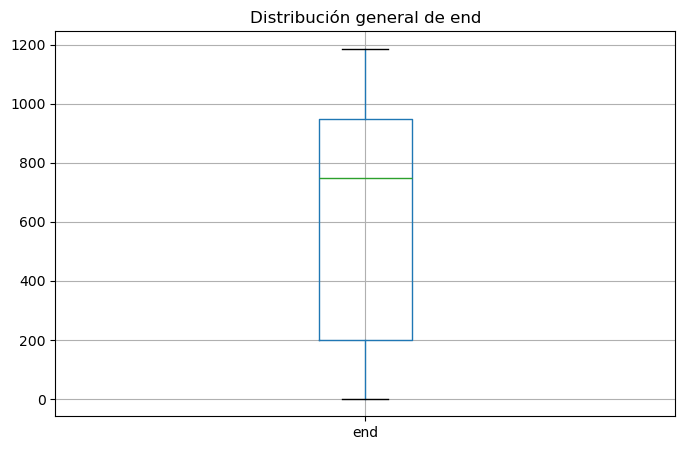

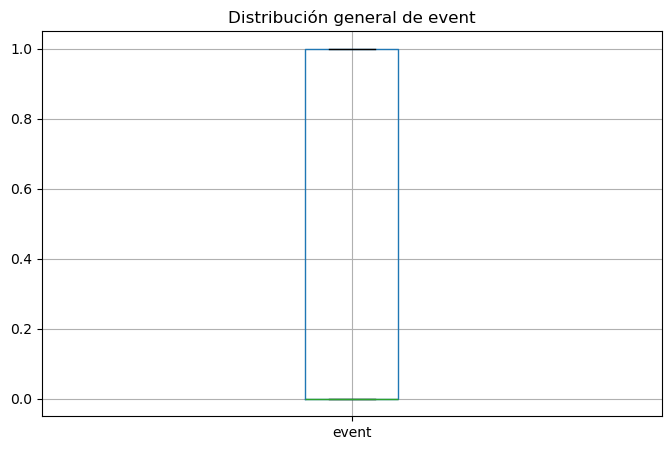

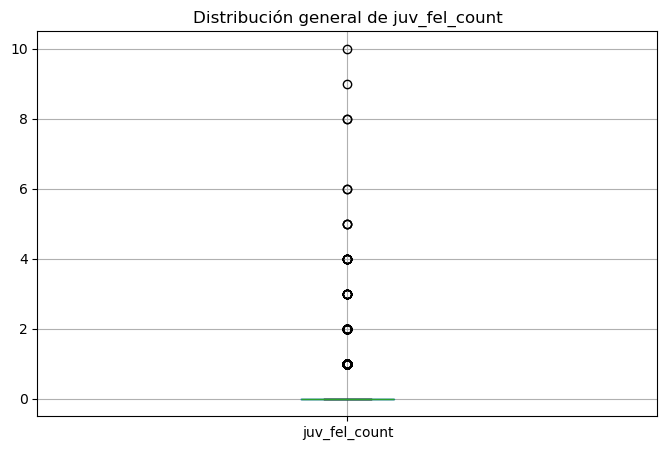

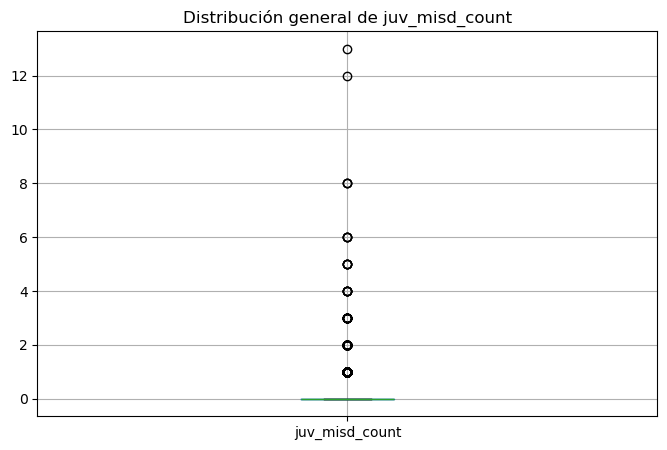

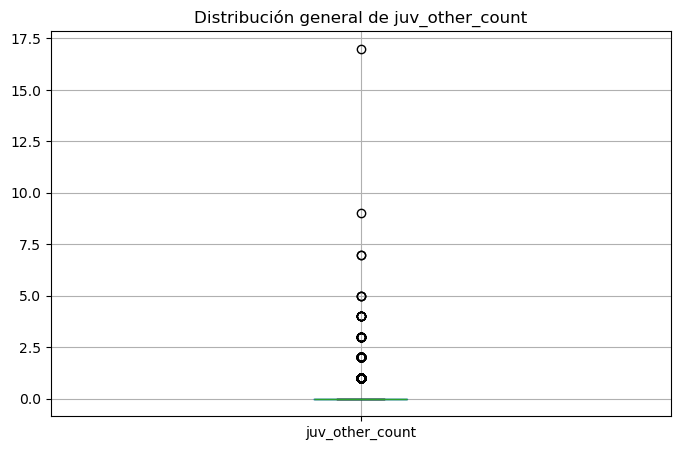

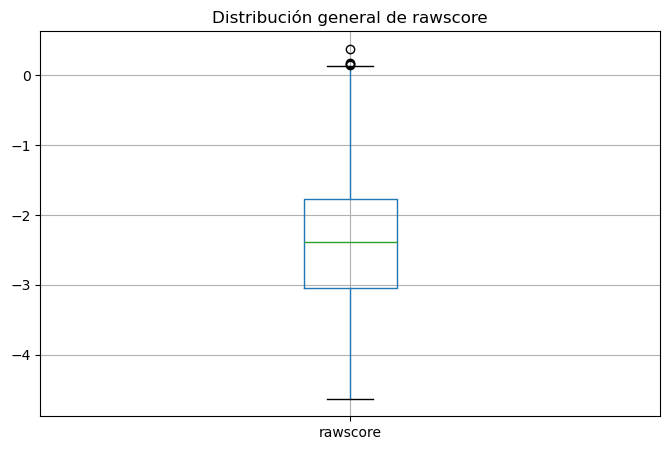

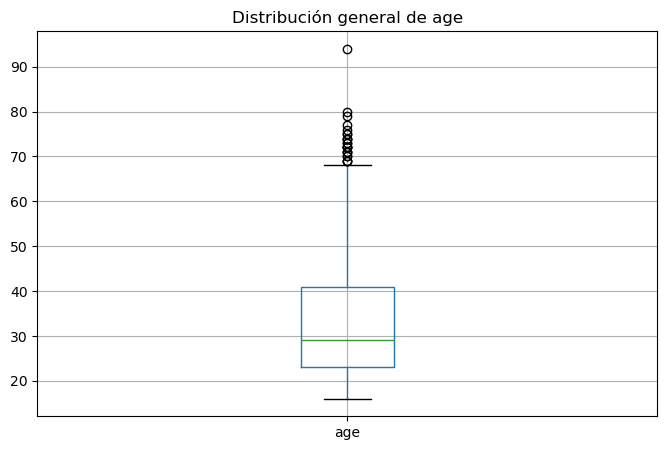

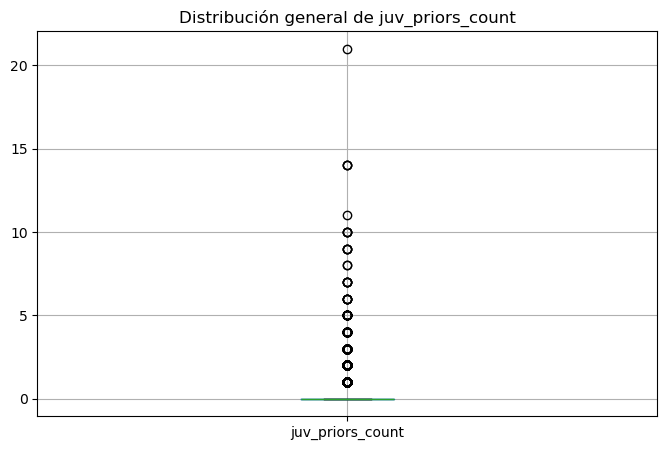

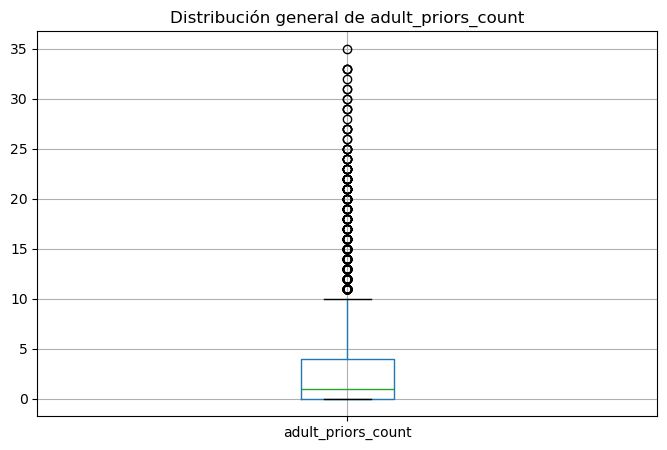

# Análisis bivariable

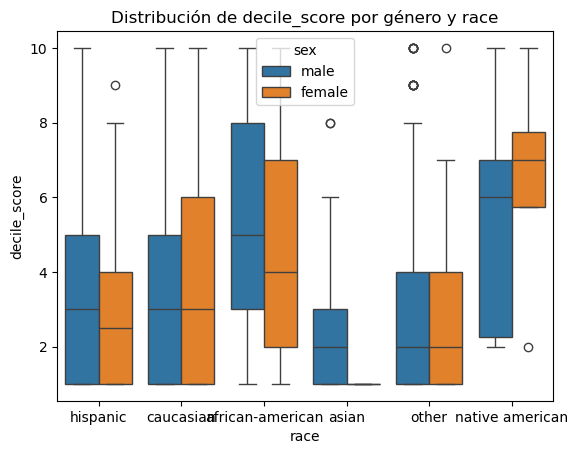

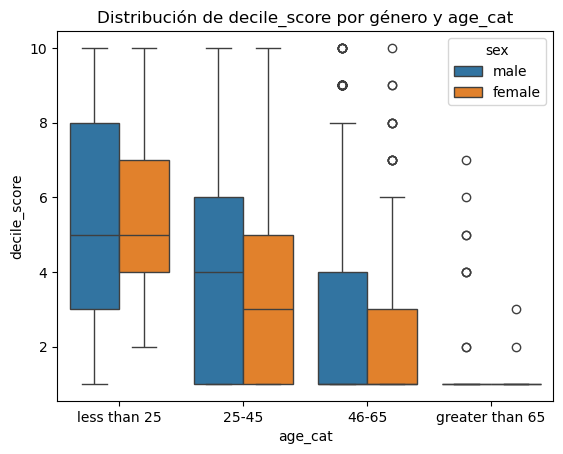

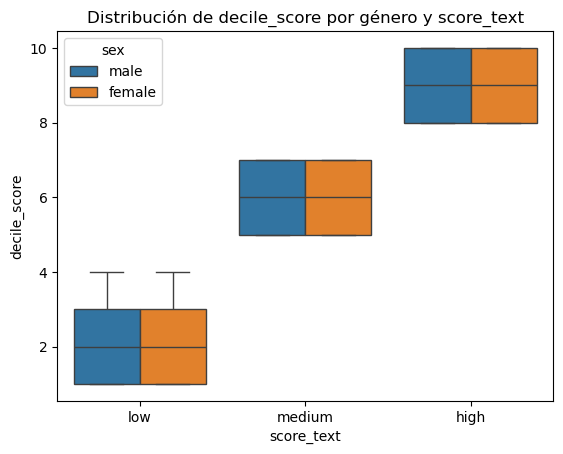

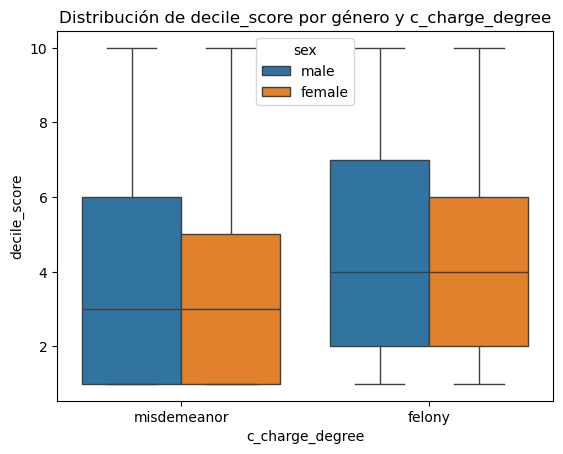

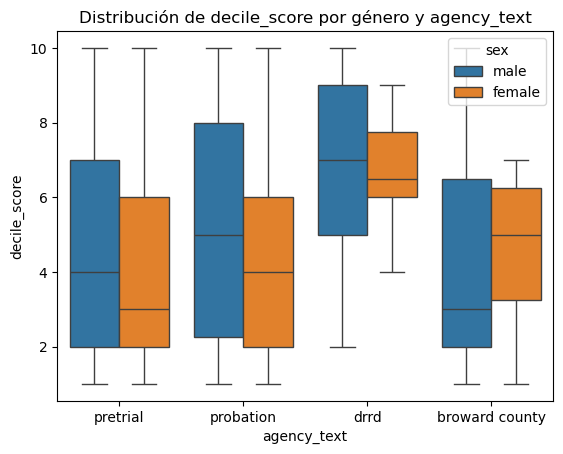

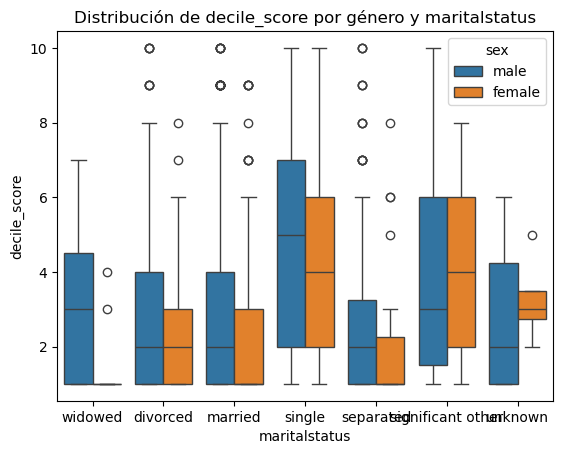

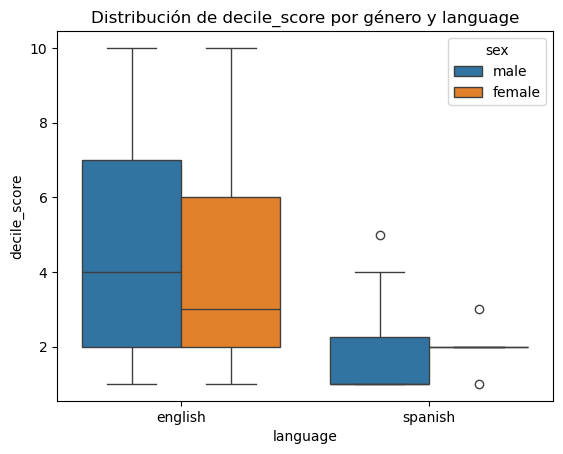

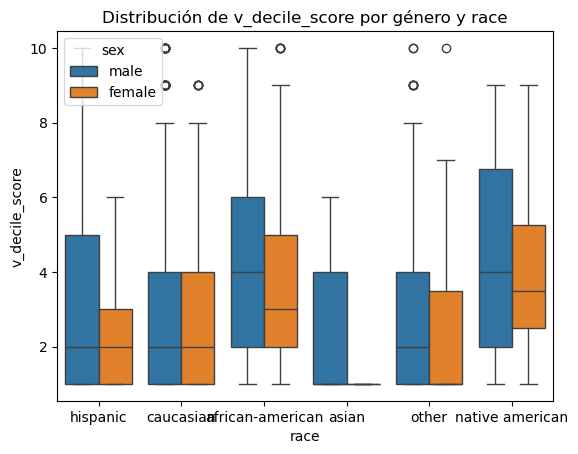

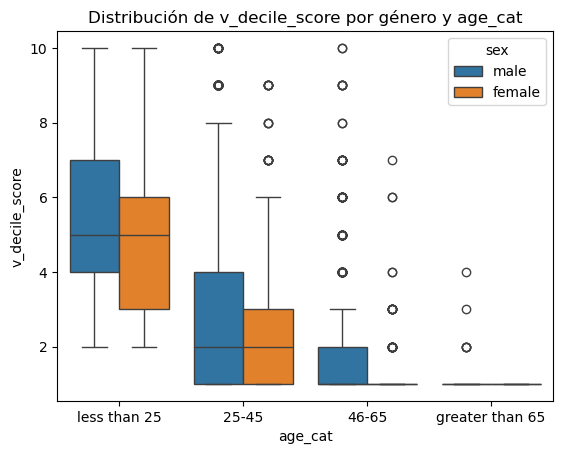

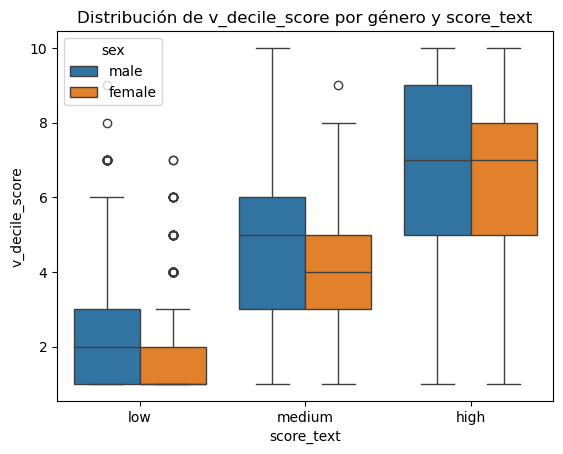

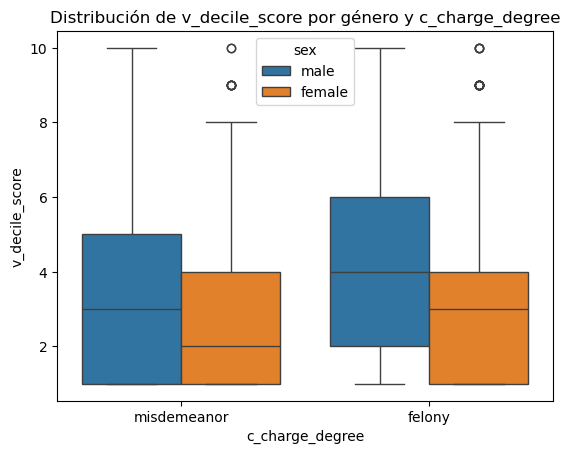

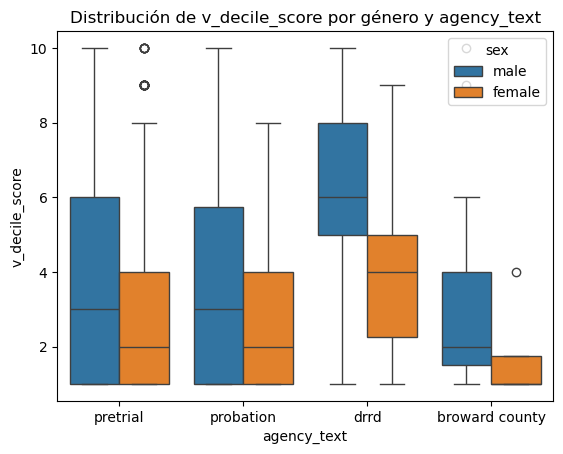

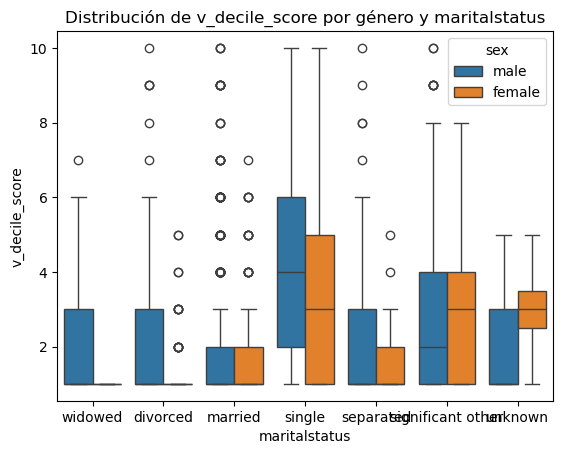

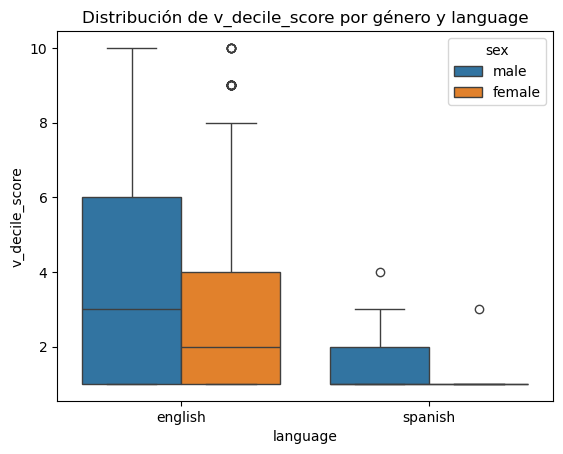

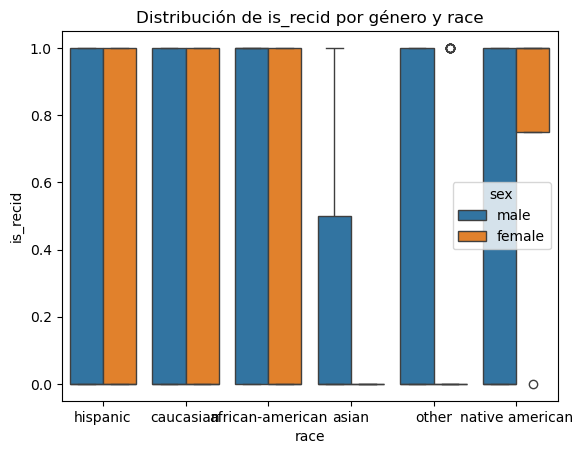

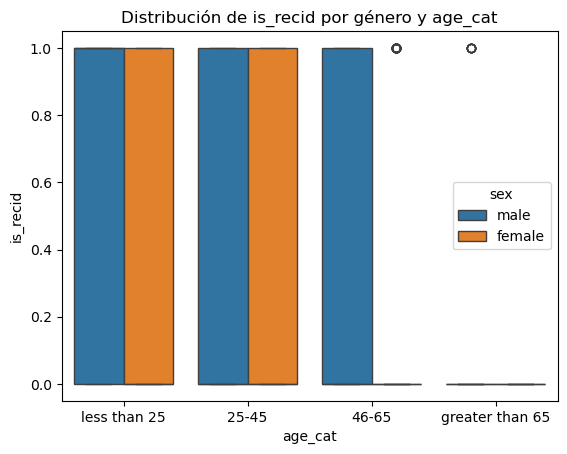

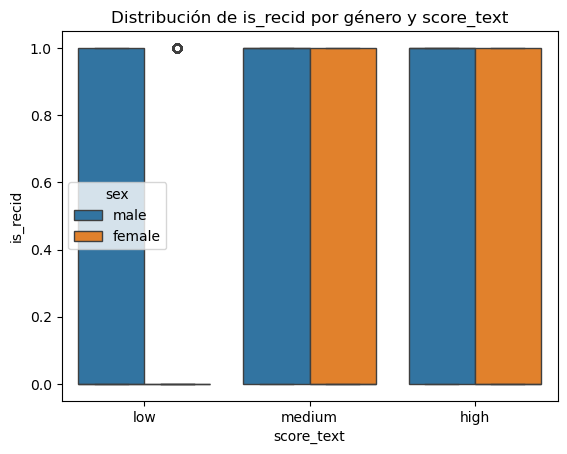

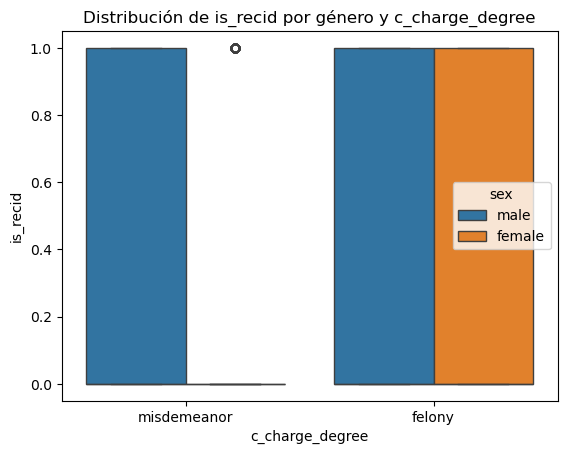

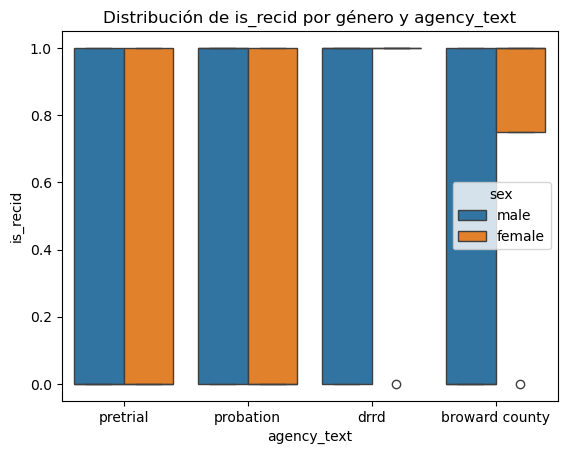

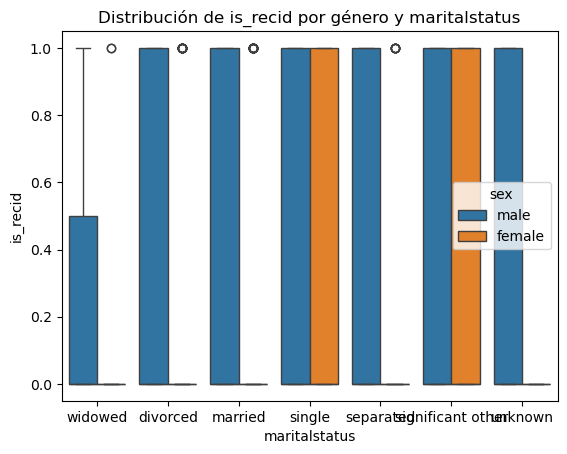

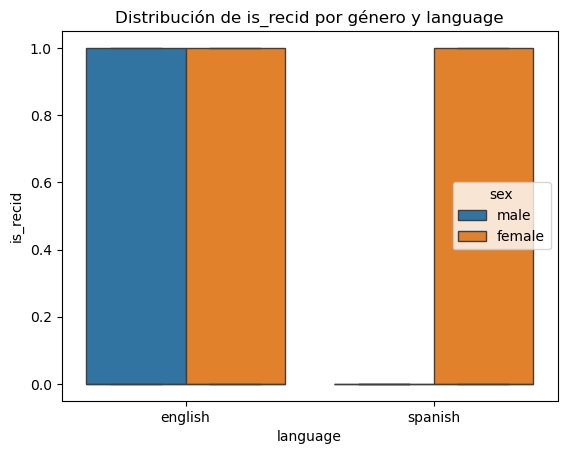

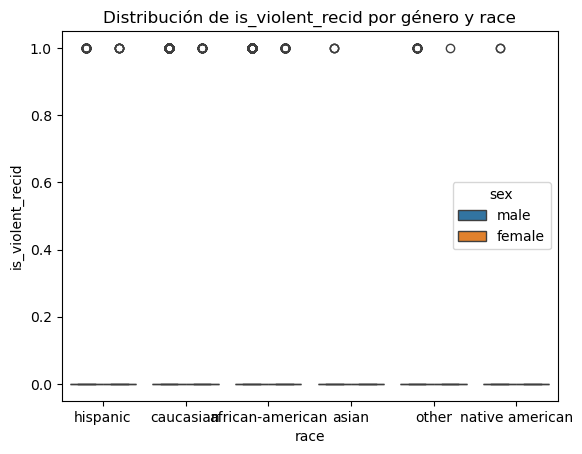

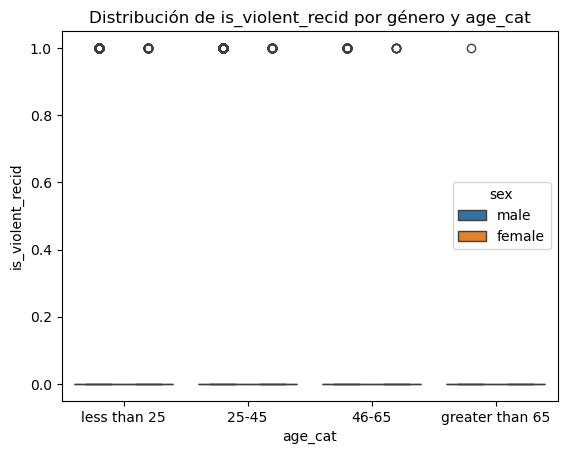

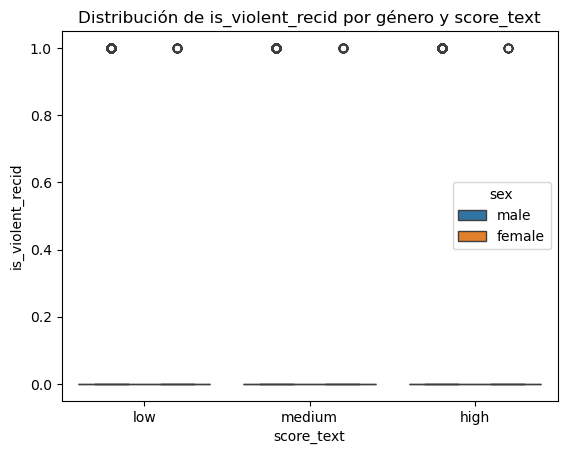

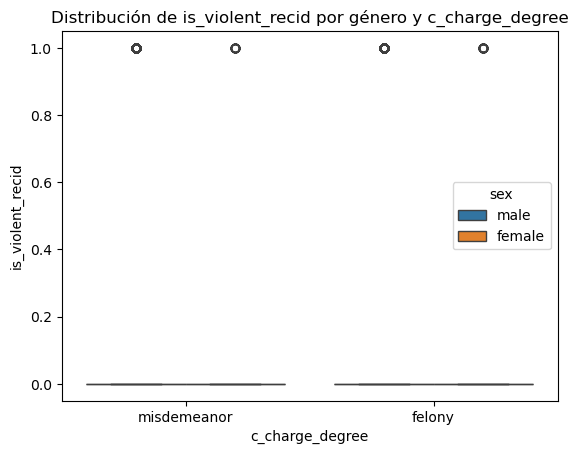

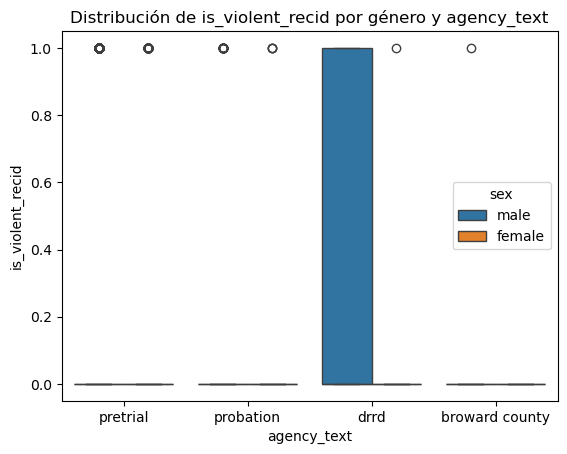

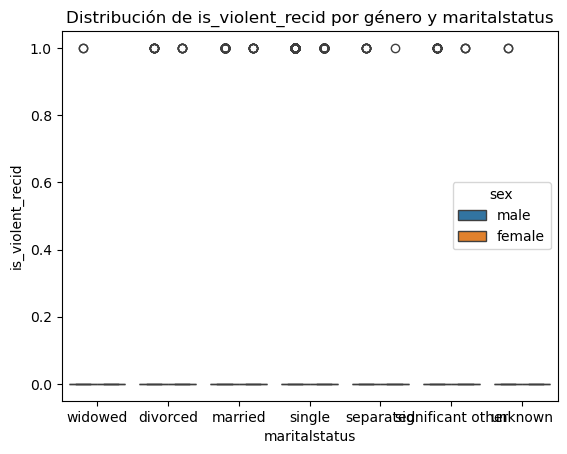

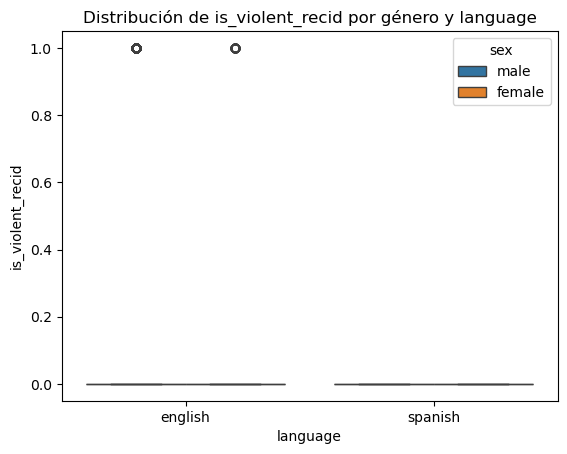

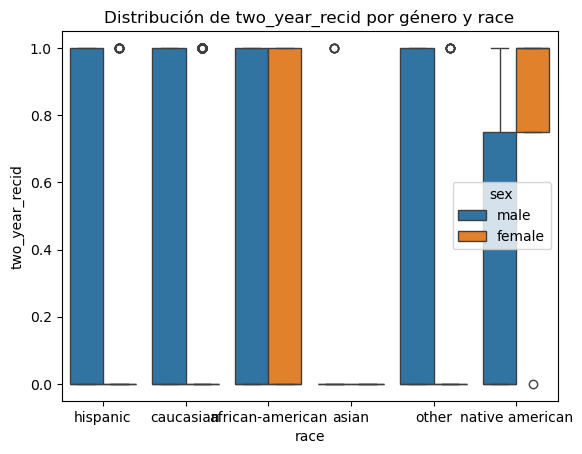

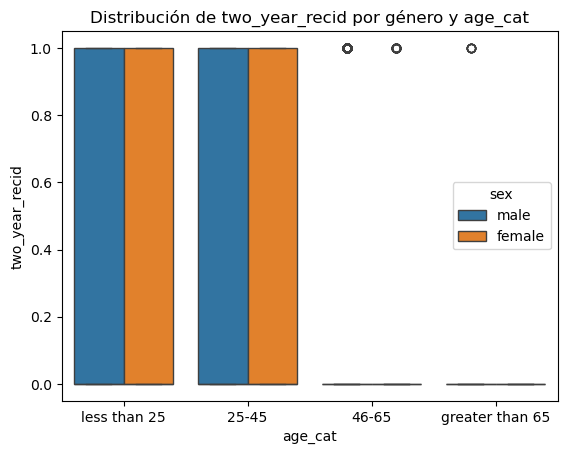

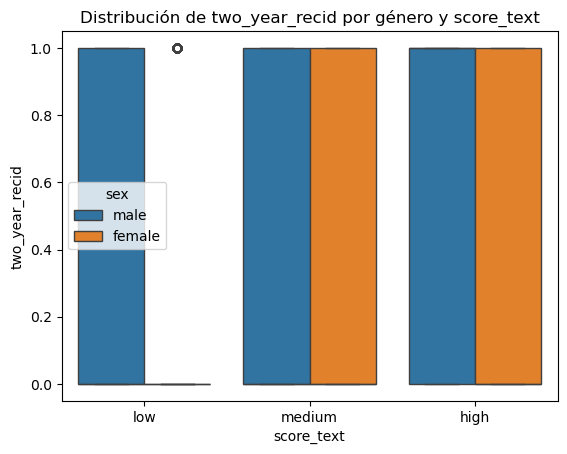

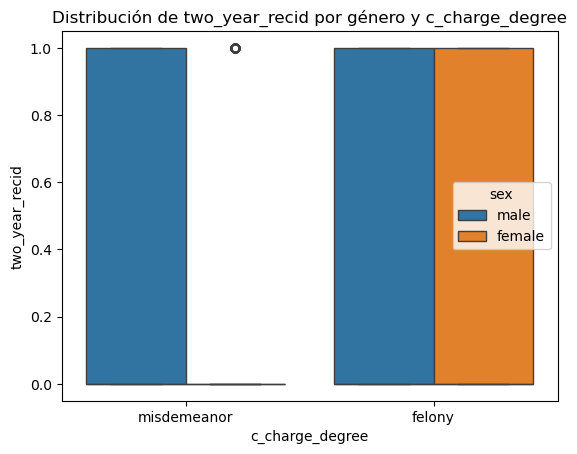

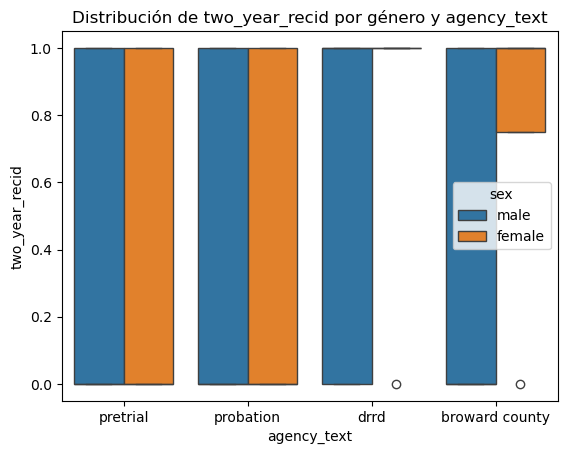

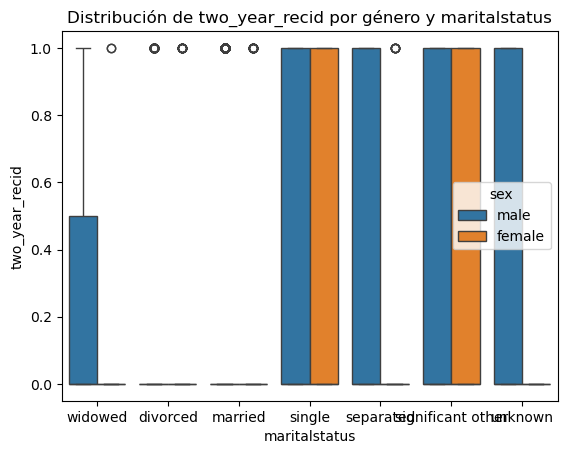

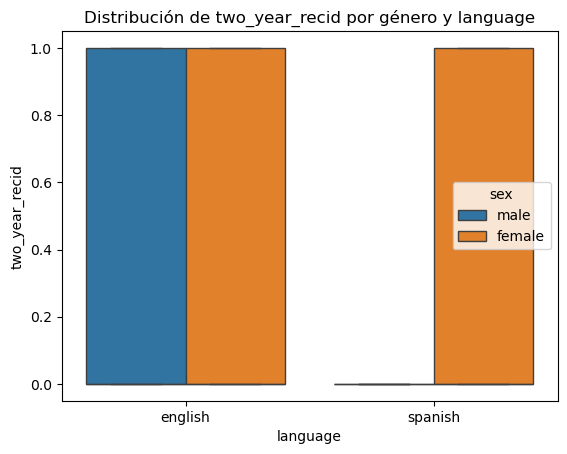

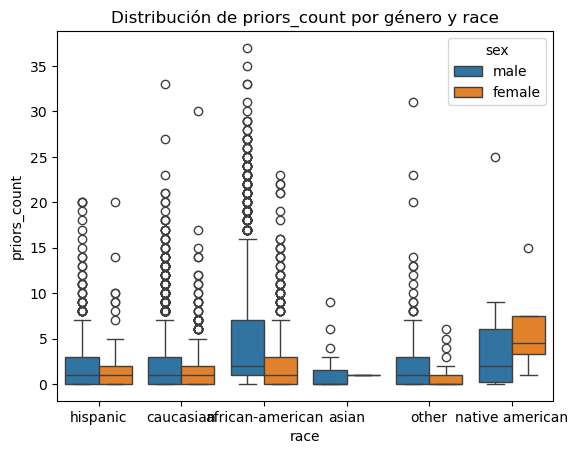

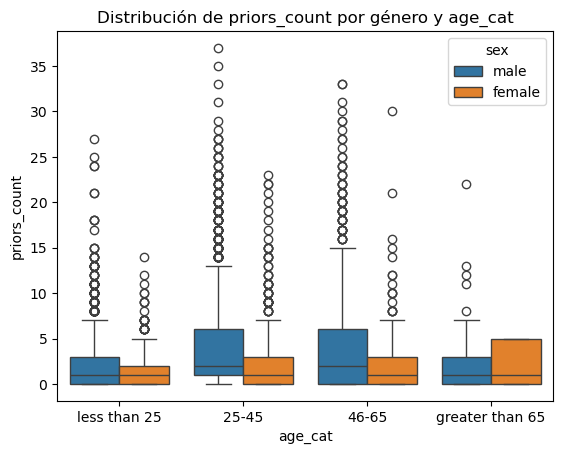

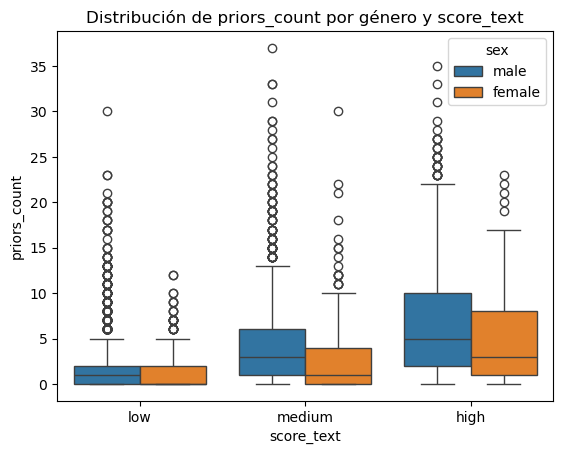

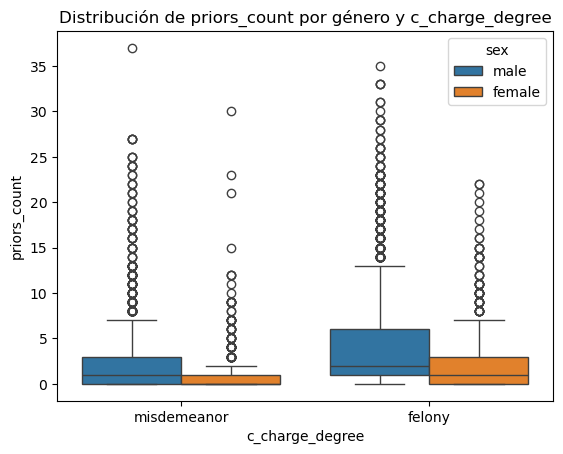

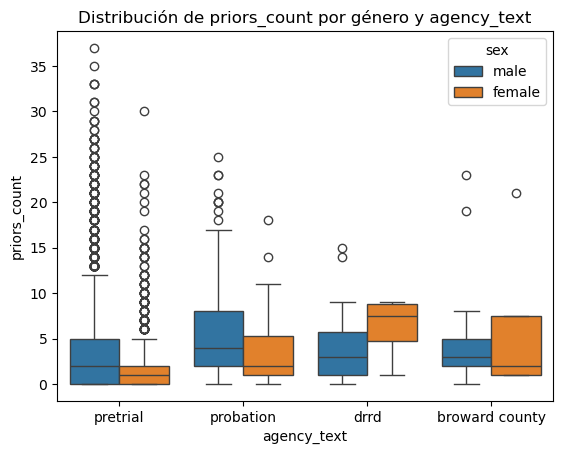

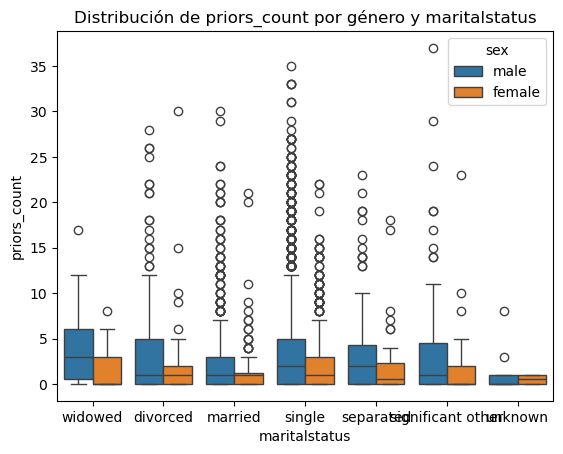

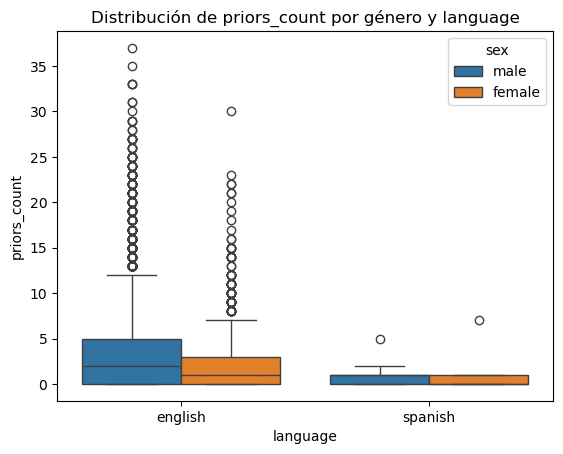

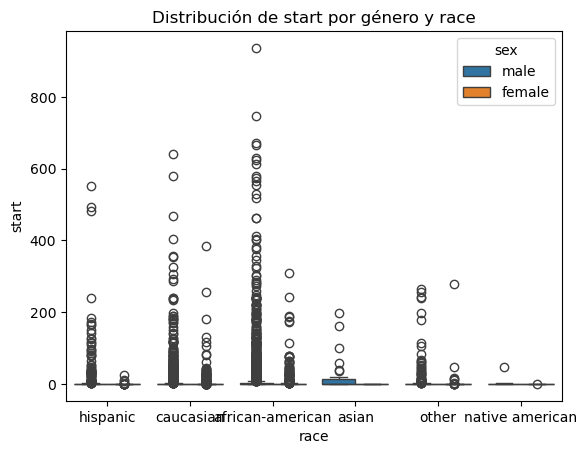

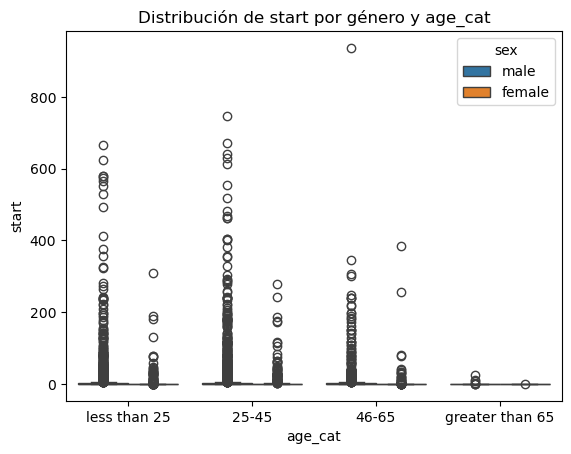

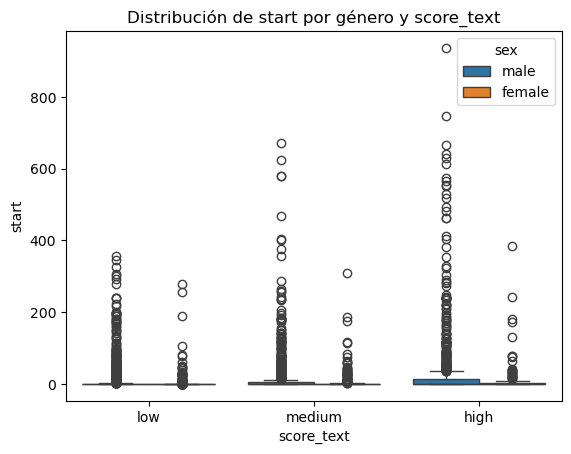

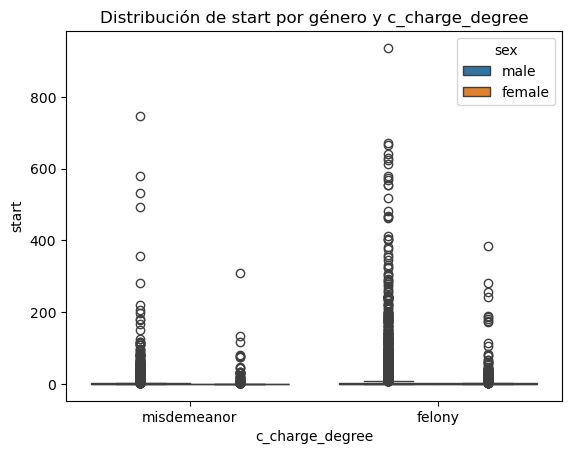

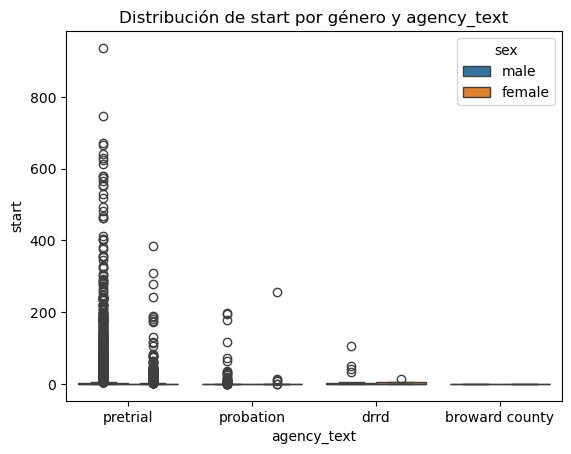

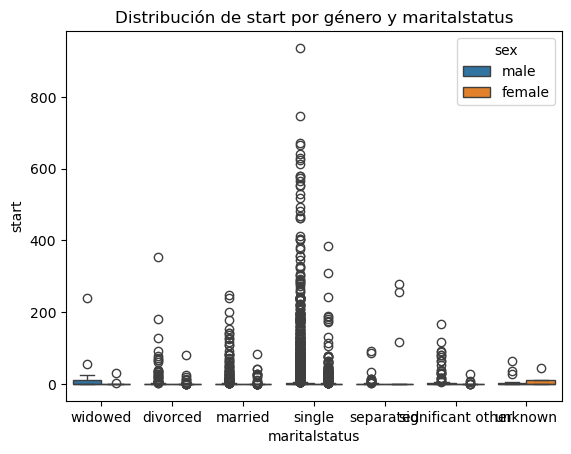

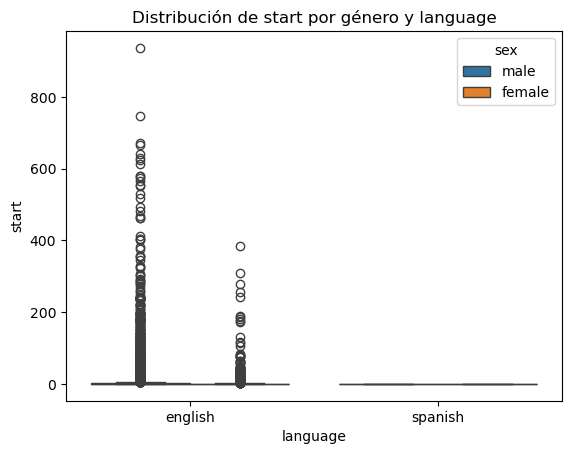

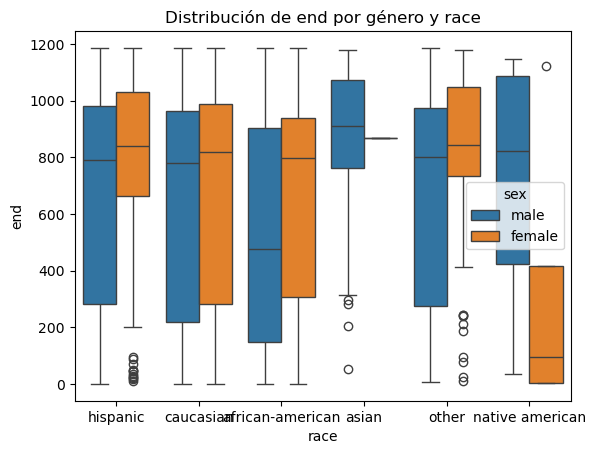

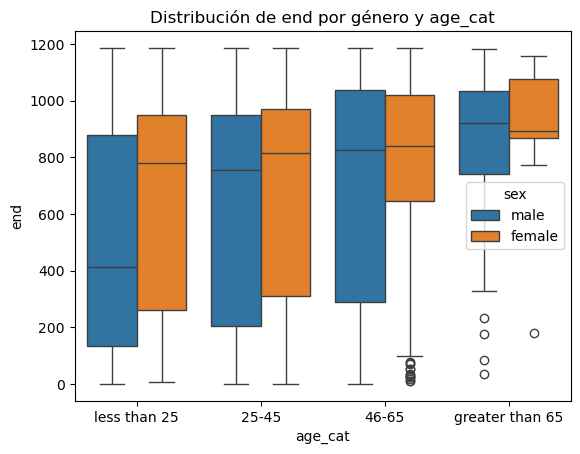

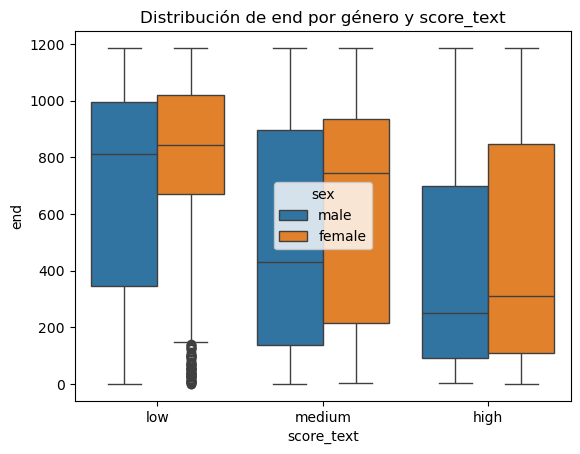

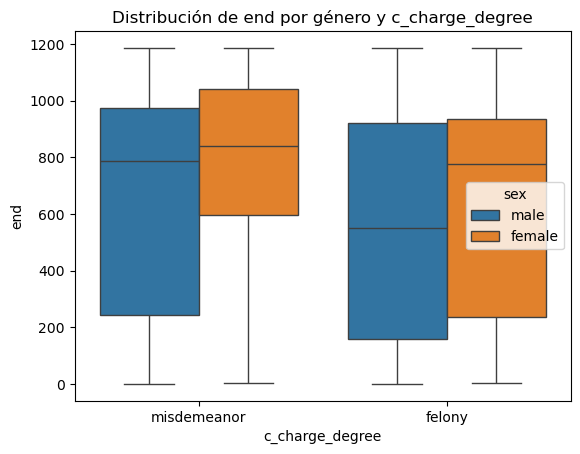

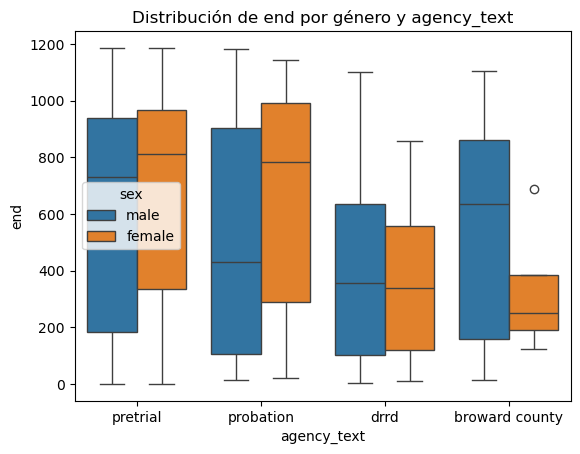

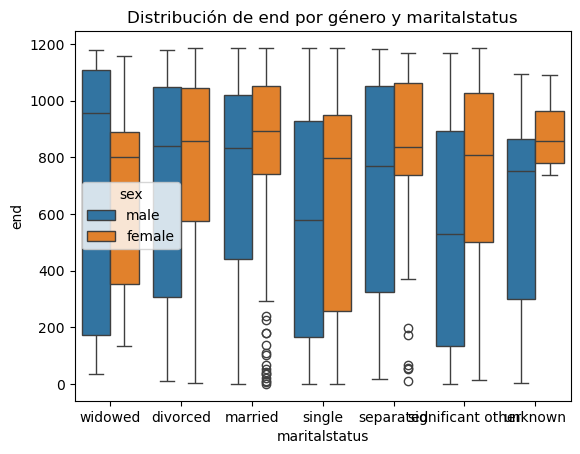

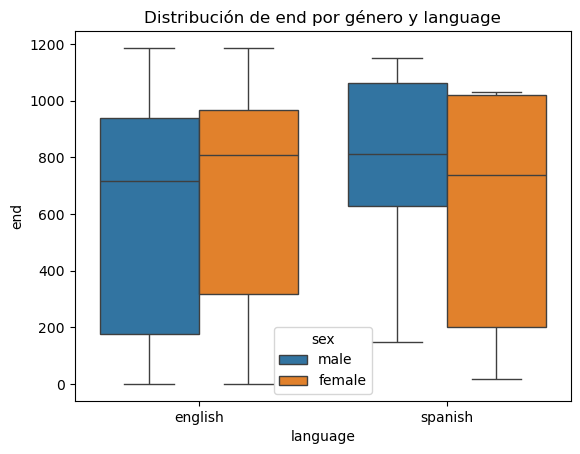

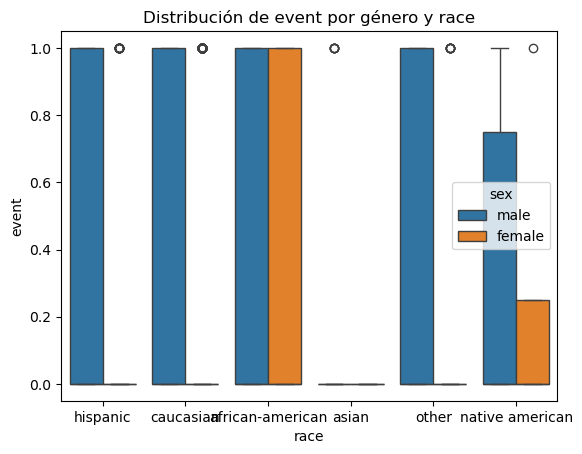

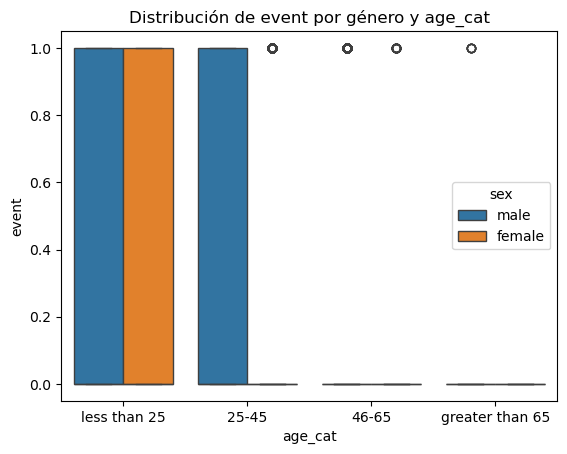

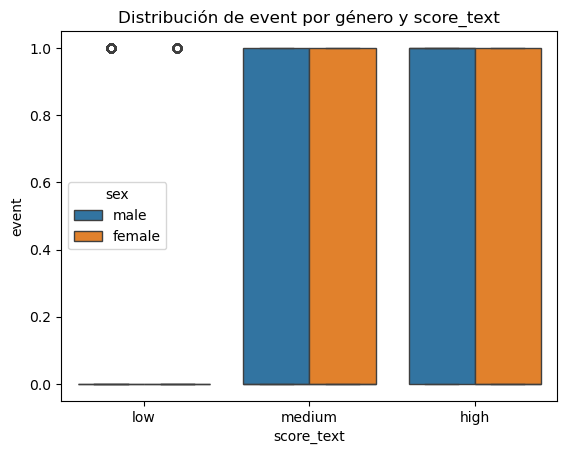

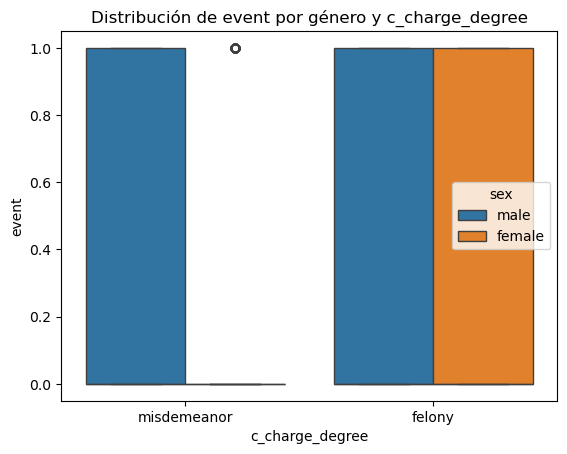

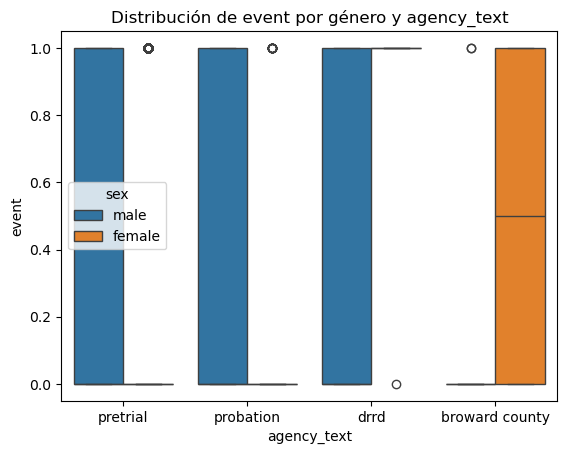

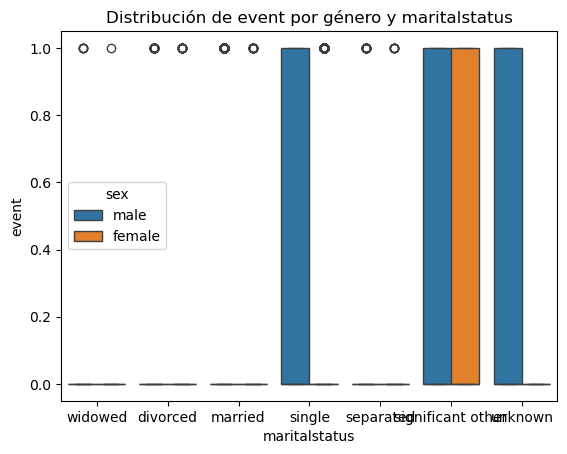

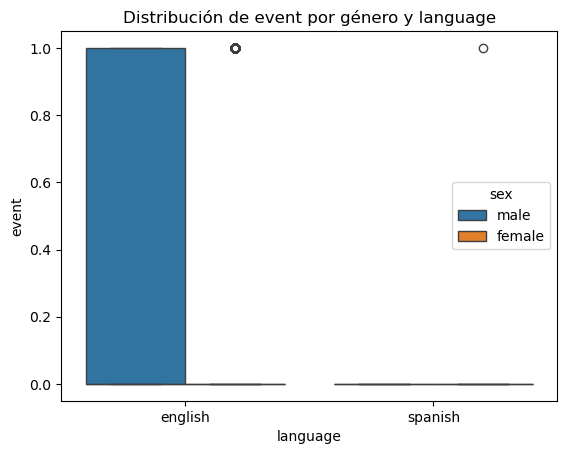

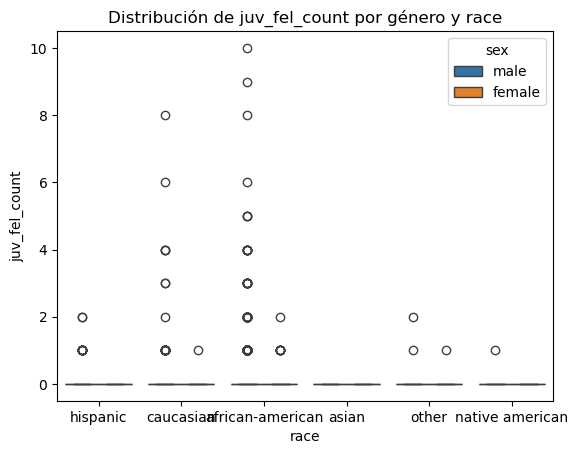

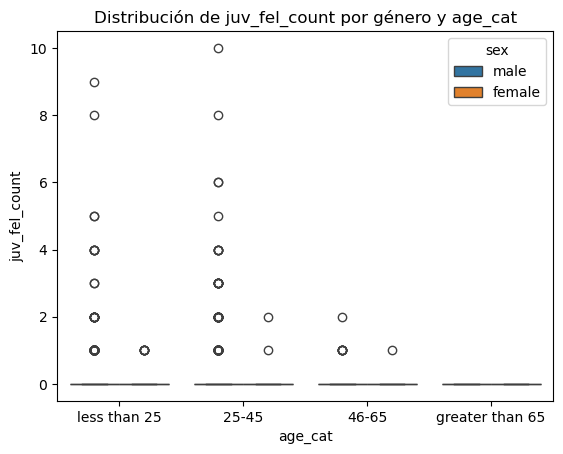

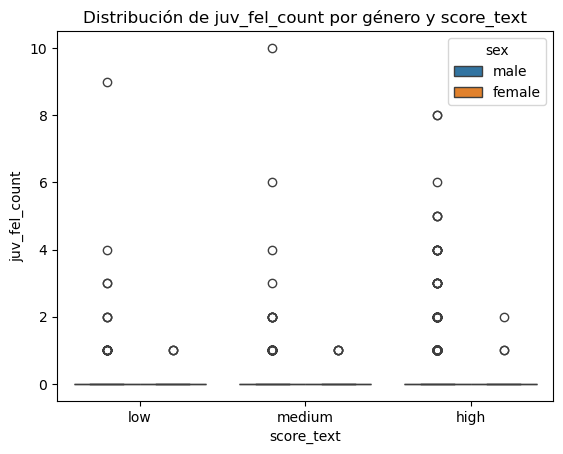

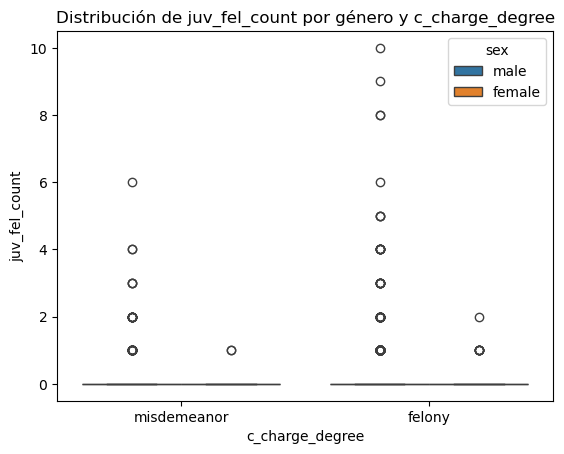

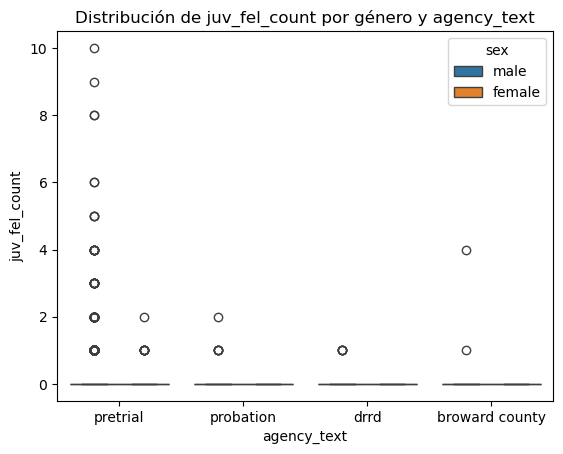

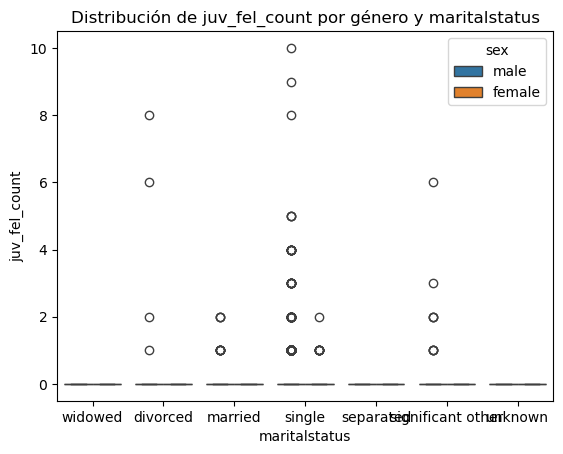

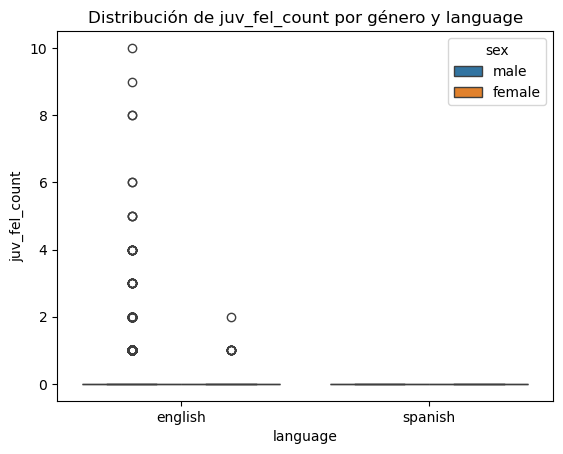

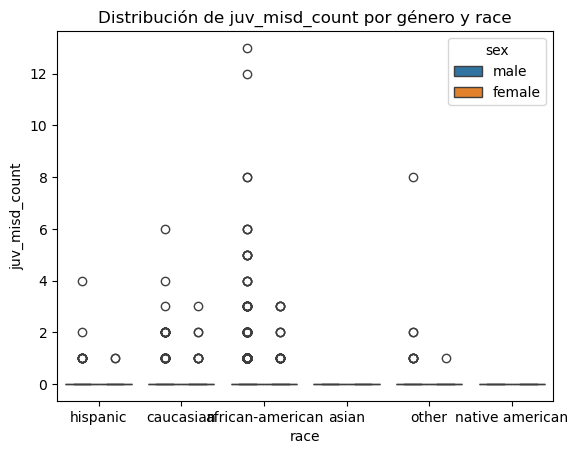

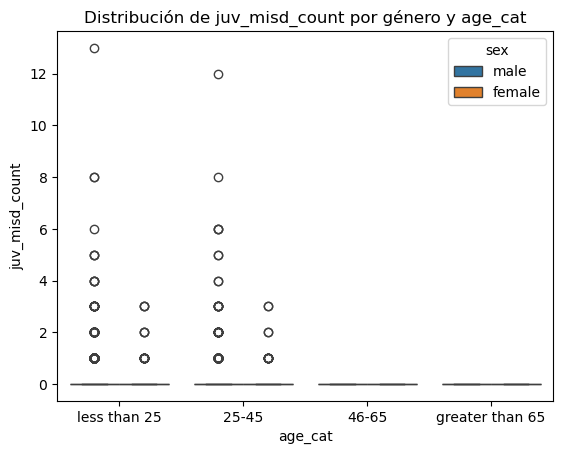

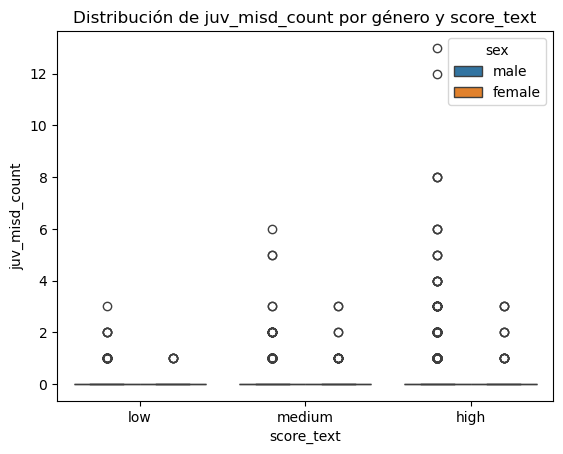

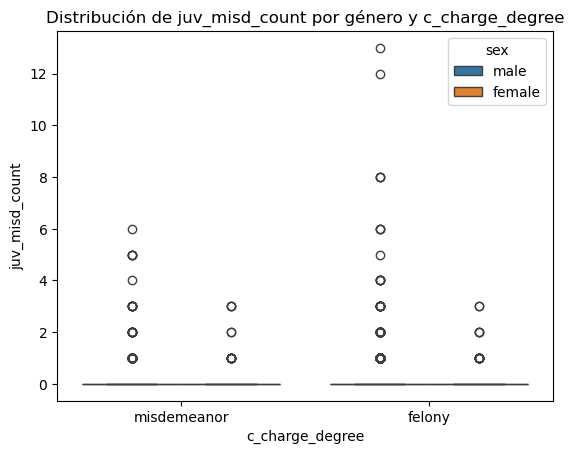

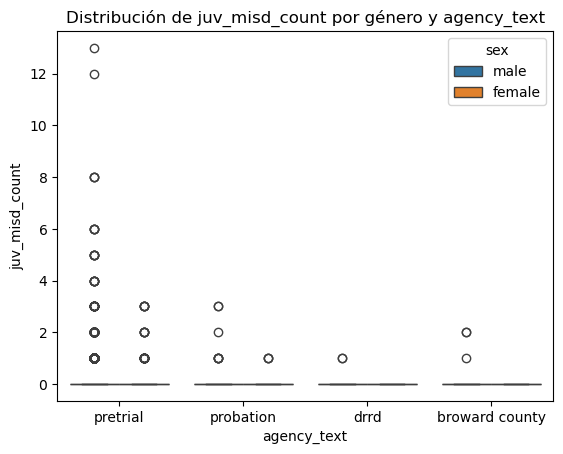

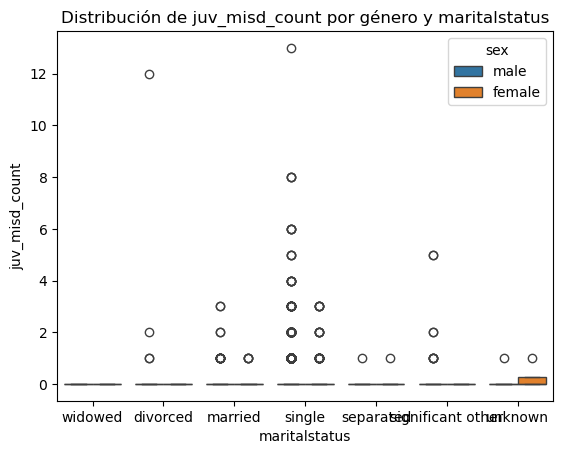

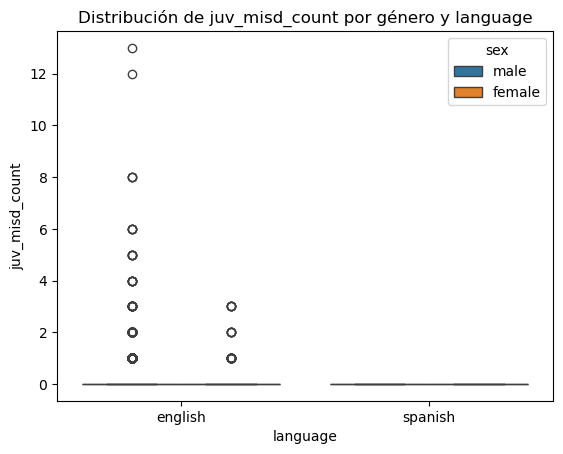

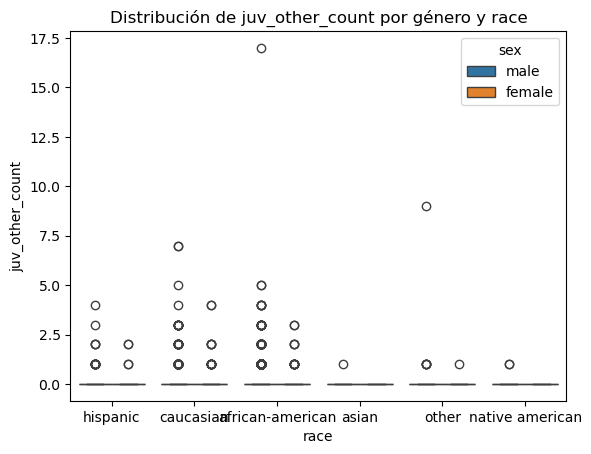

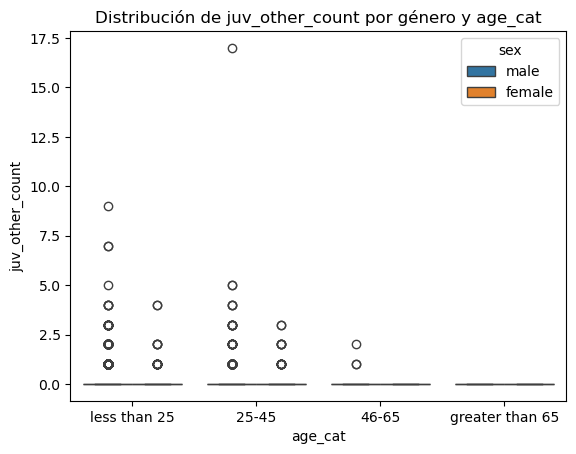

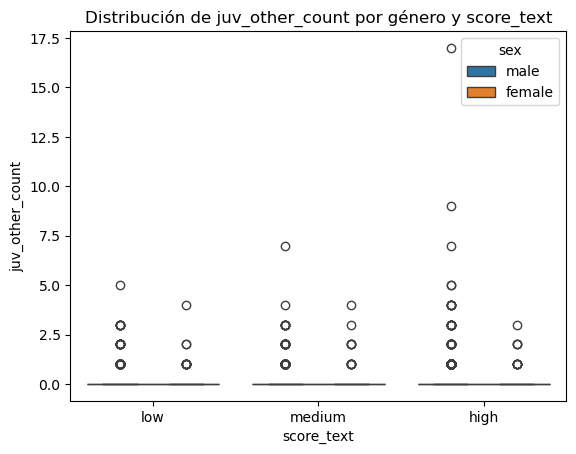

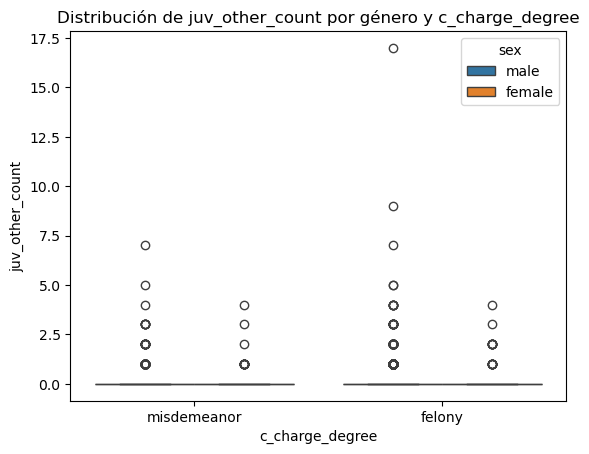

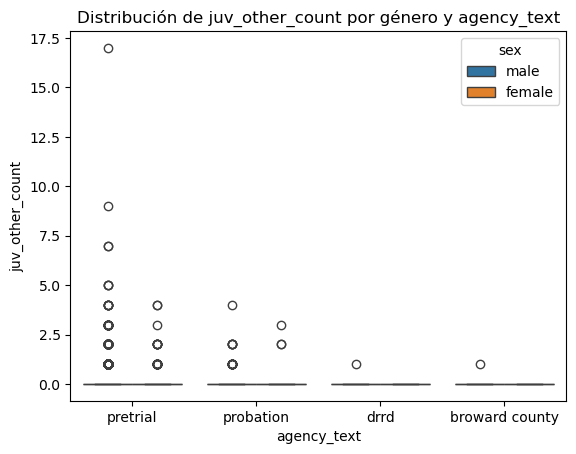

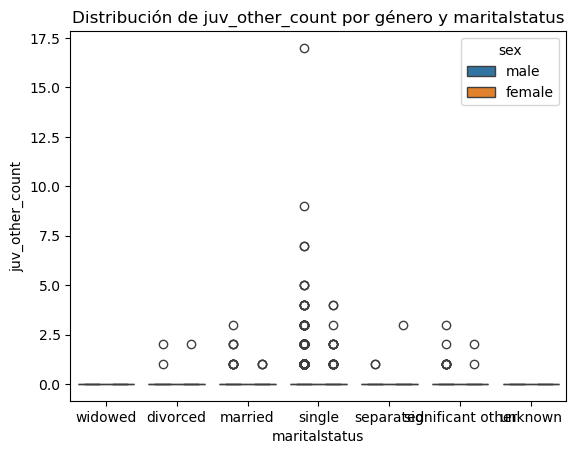

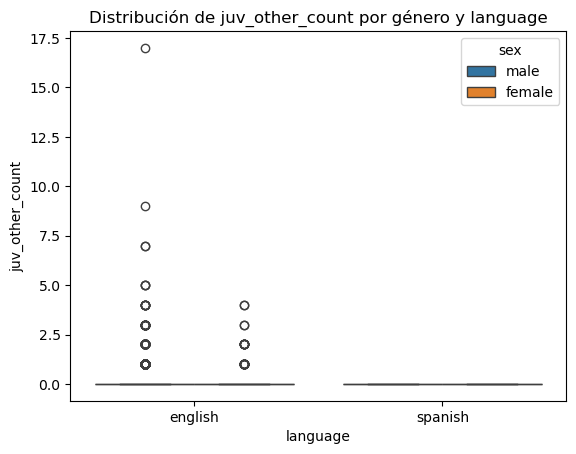

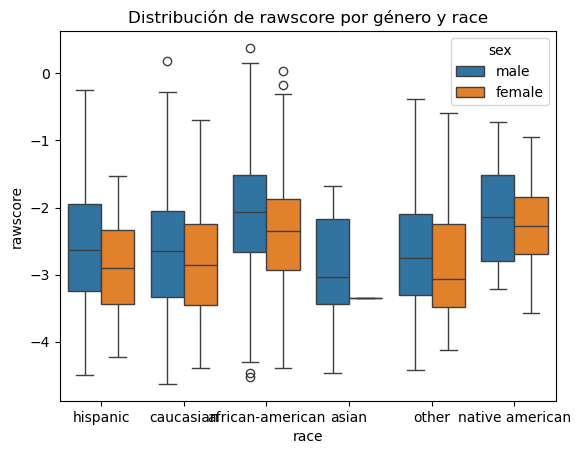

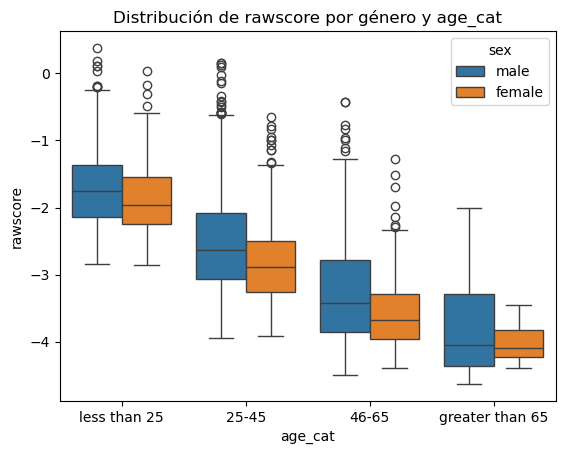

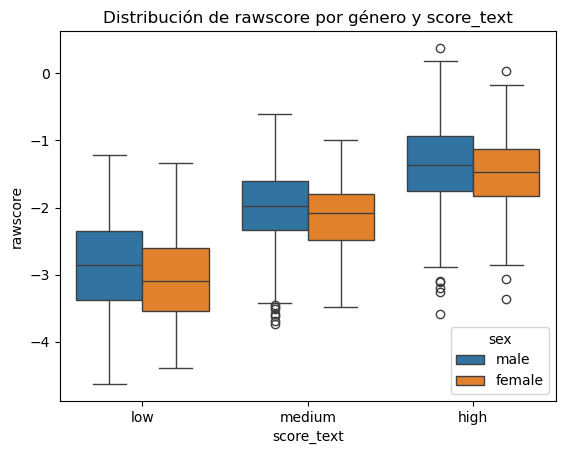

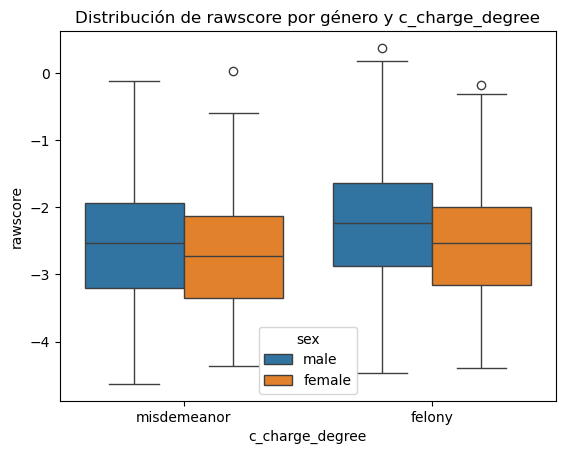

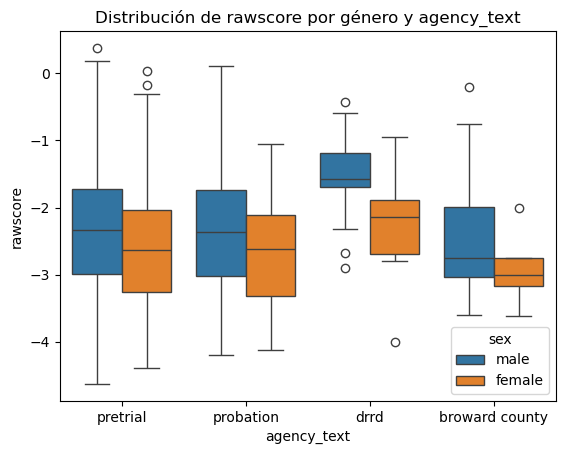

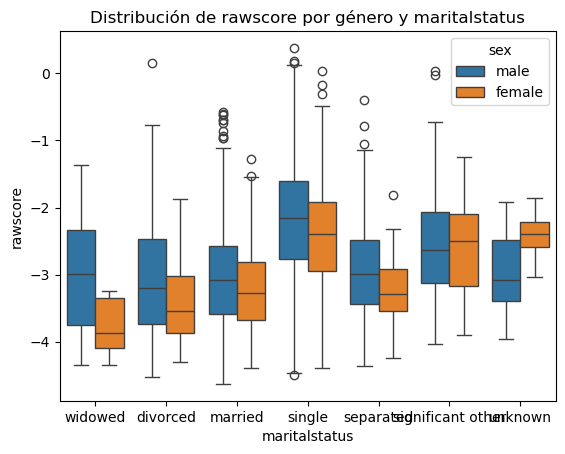

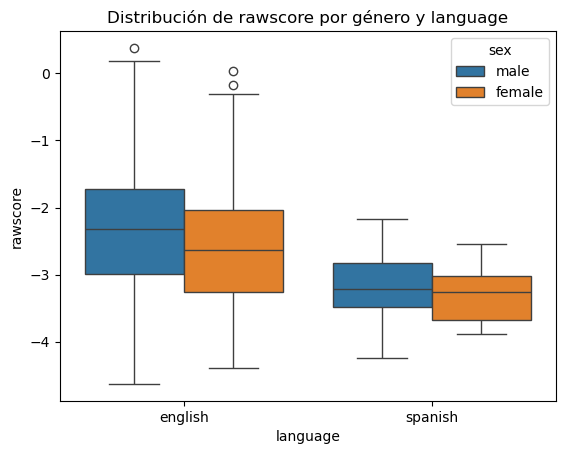

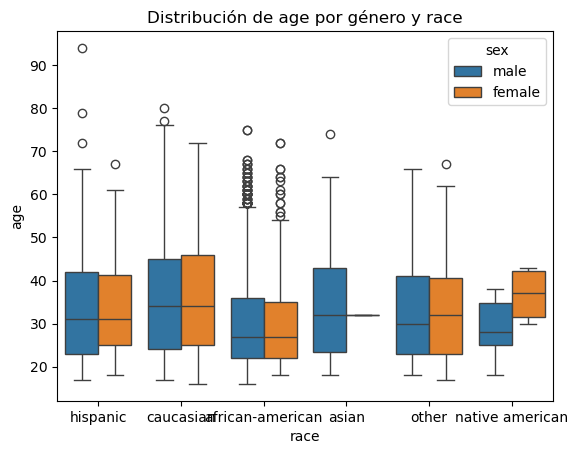

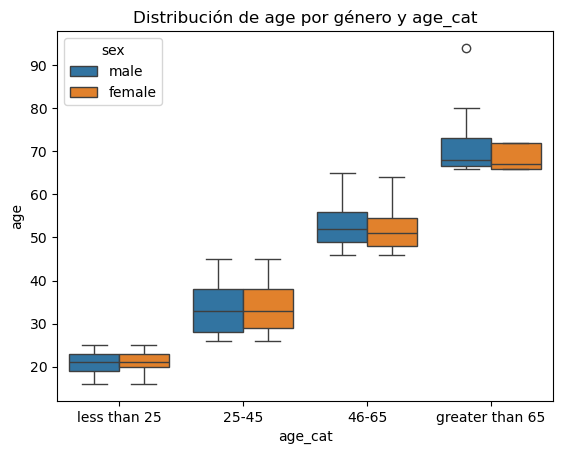

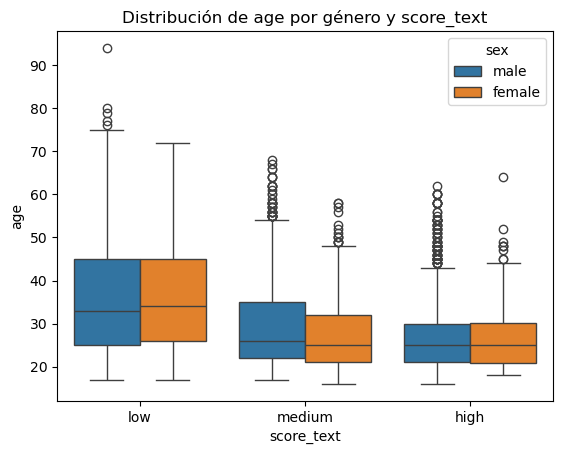

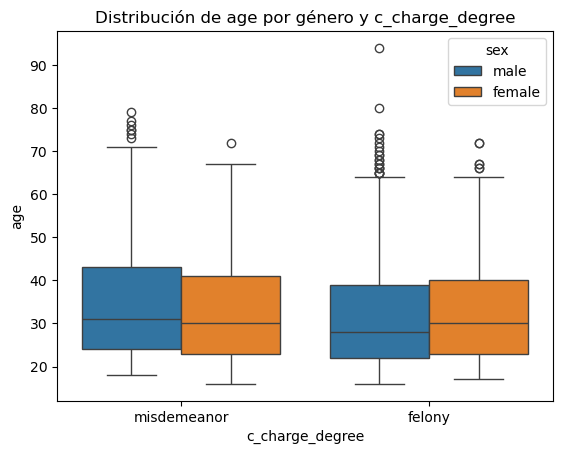

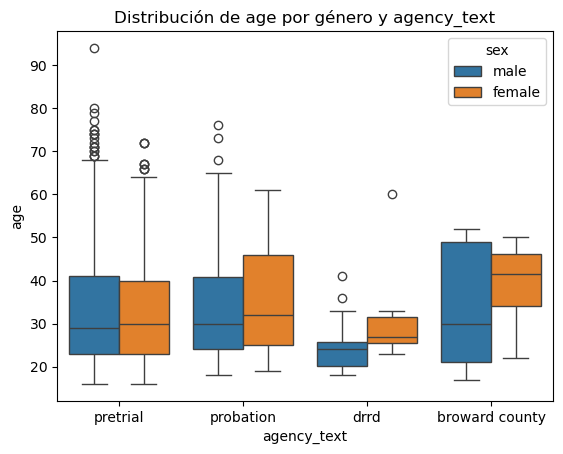

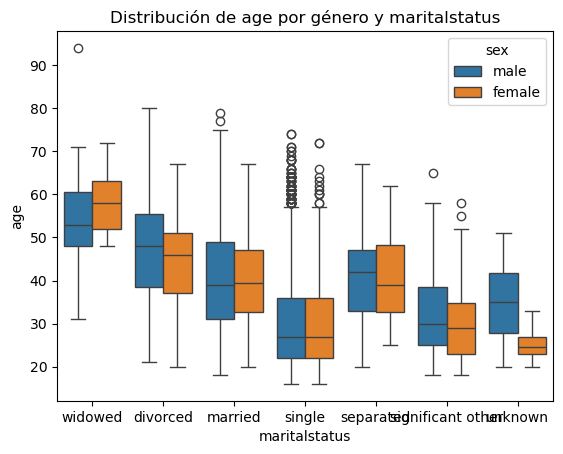

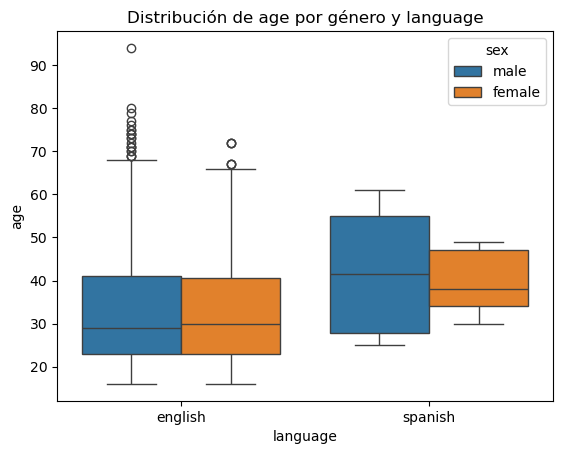

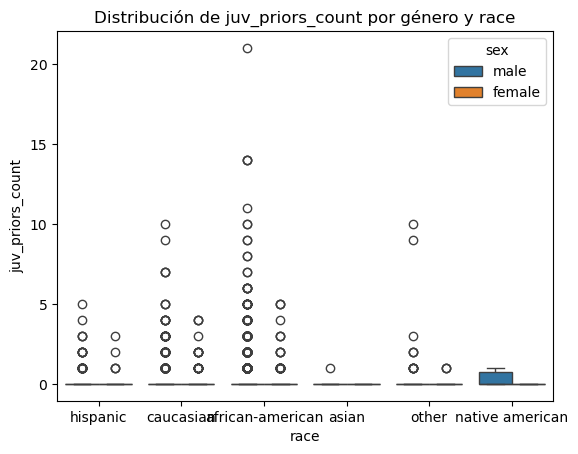

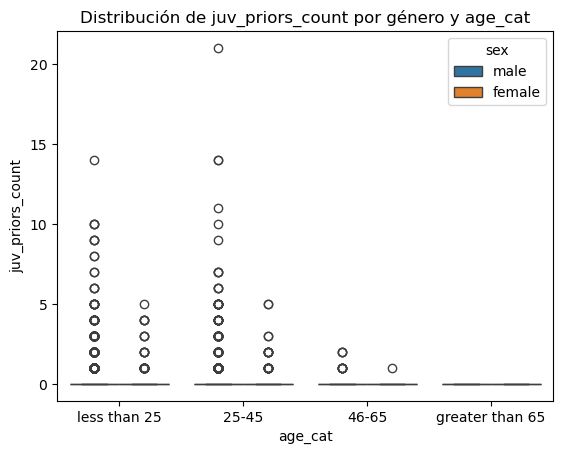

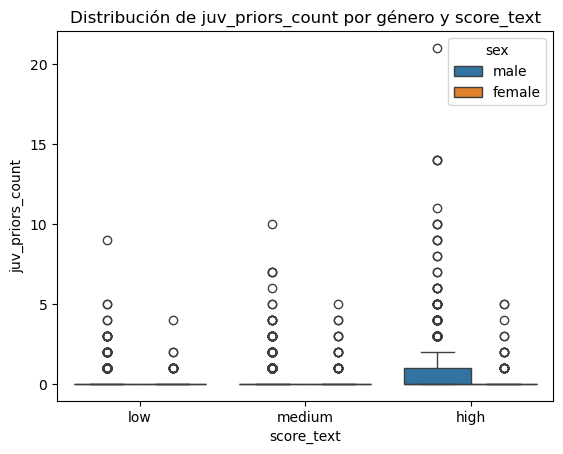

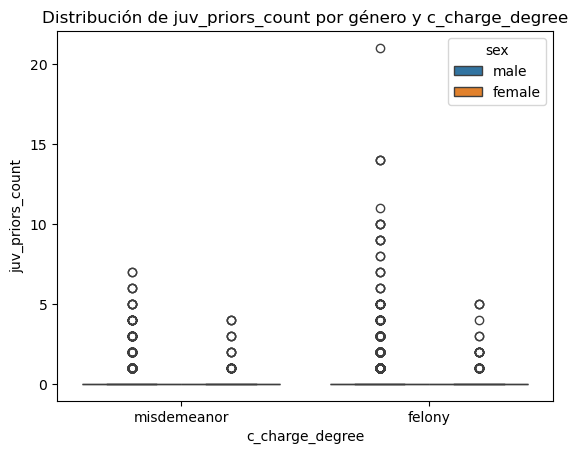

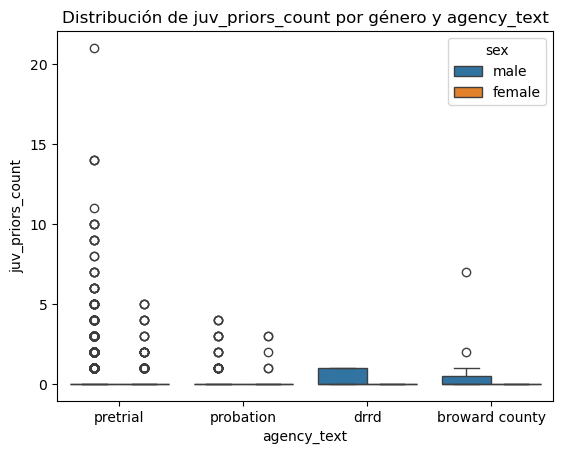

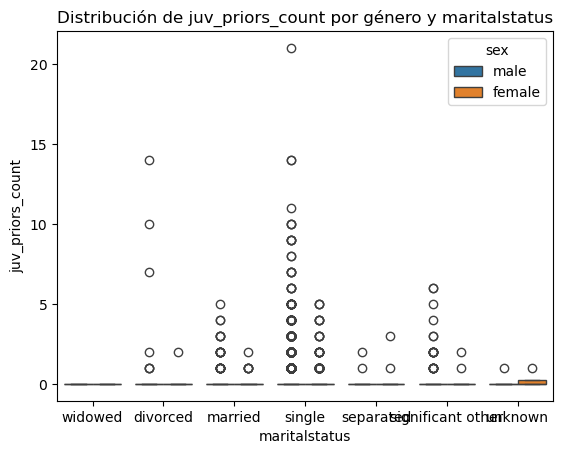

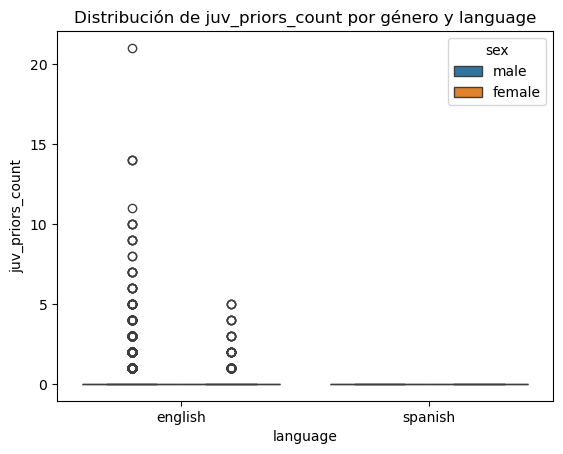

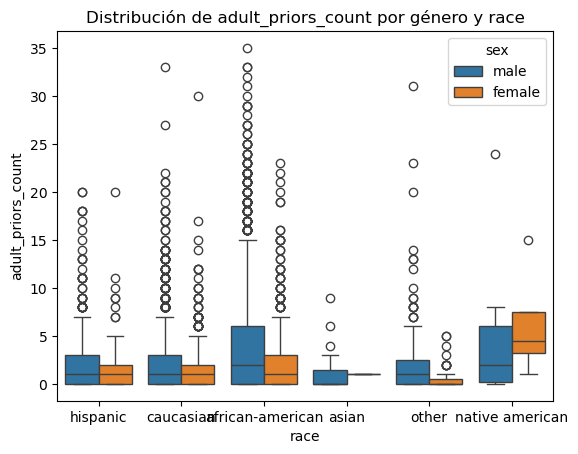

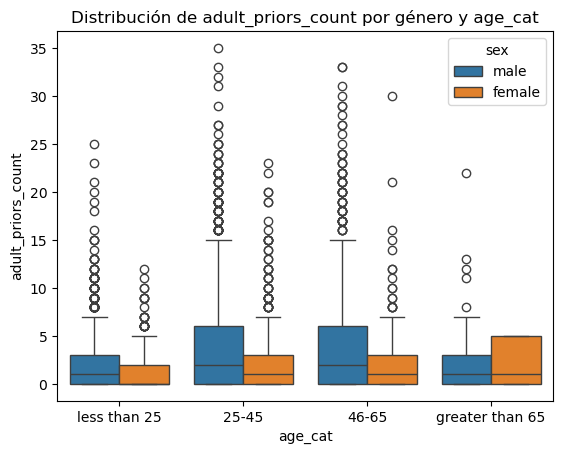

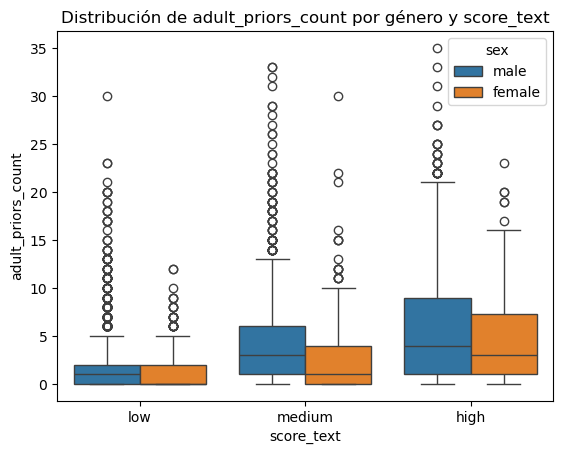

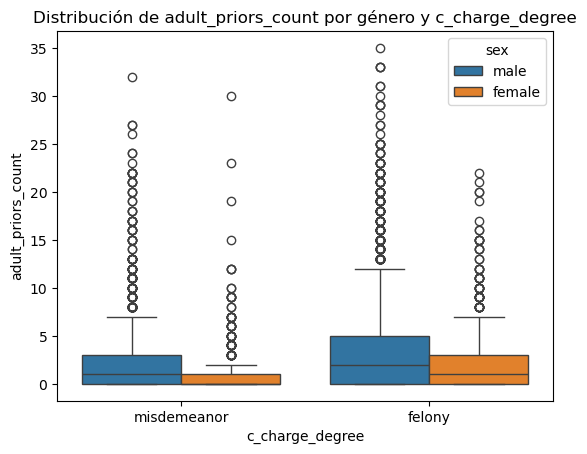

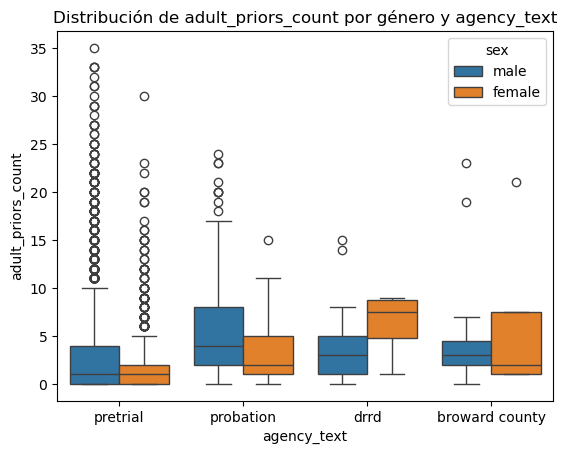

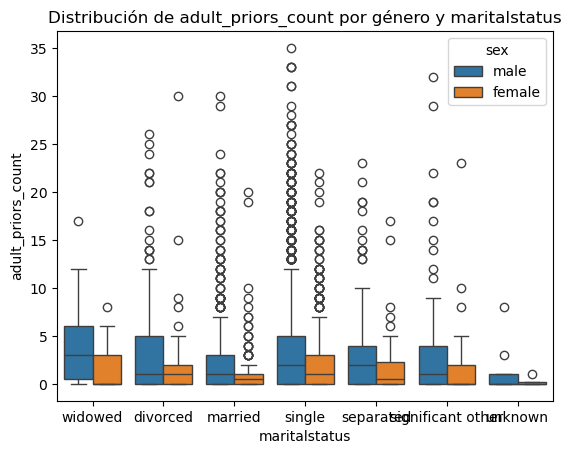

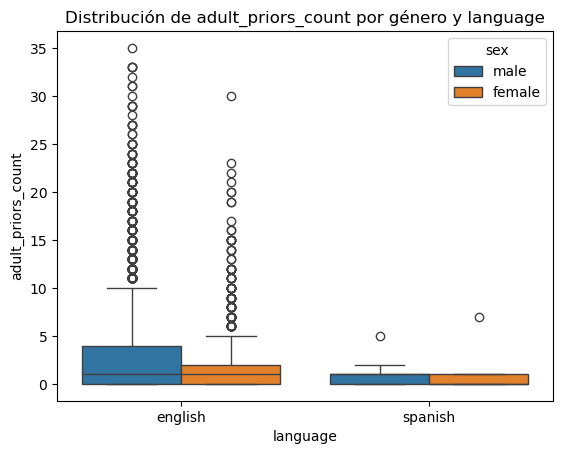

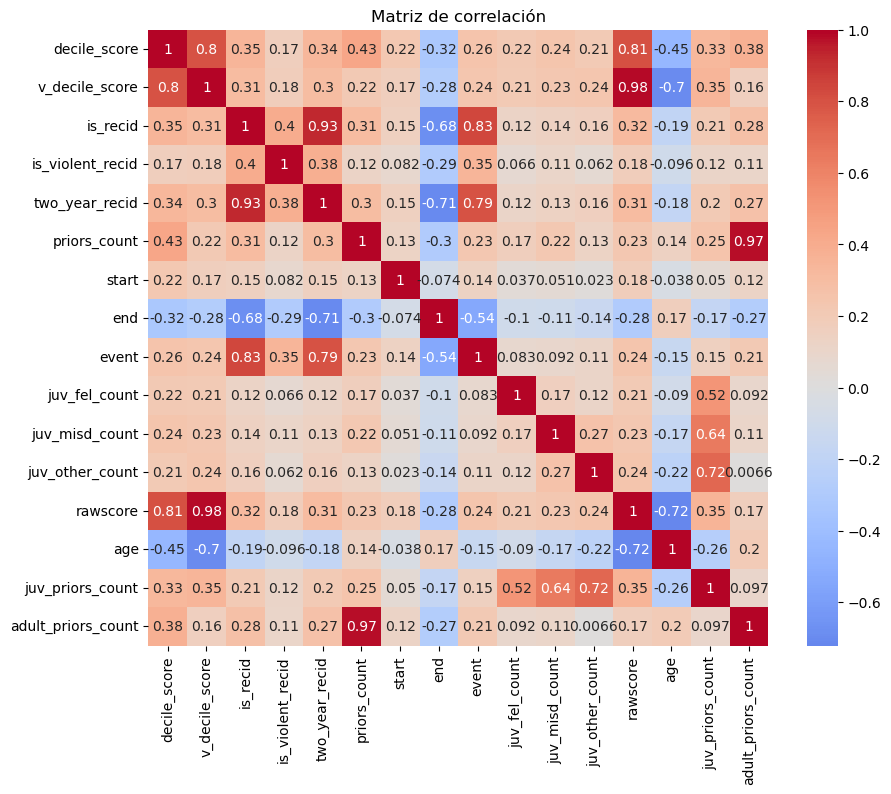


Crosstab entre sex y race


race,african-american,asian,caucasian,hispanic,native american,other,All
sex,,,,,,,
female,558,1,482,92,4,59,1196
male,2538,27,1618,469,10,279,4941
All,3096,28,2100,561,14,338,6137



Crosstab entre sex y score_text


score_text,low,medium,high,All
sex,,,,
female,725,339,132,1196
male,2753,1236,952,4941
All,3478,1575,1084,6137



Crosstab entre sex y c_charge_degree


...

is_recid,0,1,All
c_charge_degree,,,
misdemeanor,1483,770,2253
felony,2217,1667,3884
All,3700,2437,6137



Crosstab entre maritalstatus y is_recid


is_recid,0,1,All
maritalstatus,,,
divorced,202,66,268
married,550,202,752
separated,102,38,140
significant other,102,85,187
single,2704,2032,4736
unknown,17,7,24
widowed,23,7,30
All,3700,2437,6137



Crosstab entre is_recid y is_violent_recid


is_violent_recid,0,1,All
is_recid,,,
0,3700,0,3700
1,1849,588,2437
All,5549,588,6137


In [11]:
eda(df)

In [12]:
# grupos = [
#     grupo["priors_count"].values
#     for nombre, grupo in df.groupby("race")
# ]


# F, p = f_oneway(*grupos)

# print("F:", F)
# print("p-value:", p)

In [13]:
# df_count = (
#         df['ethnic_code_text']
#         .value_counts()
#         .reset_index()
#     )

In [14]:
df['prediccion'] = (df['decile_score'] >= 5).astype(int)

In [15]:
def check_bias(df):
    lista_demograficas = ['race','age_cat', 'sex', 'maritalstatus']
    for variable in lista_demograficas:
        print(f"\nVariable: {variable}")
        for grupo in df[variable].unique():
            subset = df[df[variable] == grupo]
            
            cm = confusion_matrix(subset['is_recid'], subset['prediccion'], labels=[0,1])
            cm_df = pd.DataFrame(cm, index=['Yes', 'No'], columns=['Yes', 'No'])

            cm_all = confusion_matrix(subset['is_recid'], subset['prediccion'], normalize='all', labels=[0,1])
            cm_all_df = pd.DataFrame(cm_all, index=['Yes', 'No'], columns=['Yes', 'No'])

            cm_true = confusion_matrix(subset['is_recid'], subset['prediccion'], normalize = 'true', labels=[0,1])
            cm_true_df = pd.DataFrame(cm_true, index=['Yes', 'No'], columns=['Yes', 'No'])

            print(f"\nGrupo: {grupo}")
            display(cm_df)
            print("\nNormalize All")
            display(cm_all_df)
            print("\nNormalize True")
            display(cm_true_df)

In [16]:
check_bias(df)


Variable: race

Grupo: hispanic


,Yes,No
Yes,310,81
No,92,78



Normalize All


,Yes,No
Yes,0.552585,0.144385
No,0.163993,0.139037



Normalize True


...

,Yes,No
Yes,12,5
No,6,1



Normalize All


,Yes,No
Yes,0.50,0.208333
No,0.25,0.041667



Normalize True


,Yes,No
Yes,0.705882,0.294118
No,0.857143,0.142857


In [17]:
df.columns

Index(['sex', 'race', 'age_cat', 'decile_score', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'score_text', 'screening_date', 'two_year_recid',
       'priors_count', 'c_charge_degree', 'start', 'end', 'event',
       'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'person_id',
       'agency_text', 'maritalstatus', 'language', 'rawscore', 'age',
       'juv_priors_count', 'adult_priors_count', 'prediccion'],
      dtype='object')

In [18]:
lista_aux = ["c_charge_degree", "juv_priors_count", "priors_count", "sex", "age_cat", "maritalstatus", "race", "prediccion", "is_recid", 'two_year_recid']

In [19]:
df_aux = df[lista_aux]
df_aux.head()

,c_charge_degree,juv_priors_count,priors_count,sex,age_cat,maritalstatus,race,prediccion,is_recid,two_year_recid
0,felony,0,2,male,greater than 65,widowed,hispanic,0,1,1
1,felony,0,4,male,greater than 65,divorced,caucasian,0,0,0
2,misdemeanor,0,0,male,greater than 65,married,hispanic,0,0,0
3,misdemeanor,0,0,male,greater than 65,married,caucasian,0,0,0
4,misdemeanor,0,1,male,greater than 65,divorced,caucasian,0,0,0


In [20]:
df_aux['priors_count_cat'] = pd.qcut(df_aux['priors_count'], q=3, labels=['Bajo', 'Medio', 'Alto'])
df_aux['priors_count_cat'] = pd.Categorical(df_aux['priors_count_cat'], categories = ['Bajo', 'Medio', 'Alto'], ordered = True)

df_aux["juv_priors_flag"] = (df_aux["juv_priors_count"] > 0).map({True: "Sí", False: "No"})

In [21]:
df_aux.head()

,c_charge_degree,juv_priors_count,priors_count,sex,age_cat,maritalstatus,race,prediccion,is_recid,two_year_recid,priors_count_cat,juv_priors_flag
0,felony,0,2,male,greater than 65,widowed,hispanic,0,1,1,Medio,No
1,felony,0,4,male,greater than 65,divorced,caucasian,0,0,0,Alto,No
2,misdemeanor,0,0,male,greater than 65,married,hispanic,0,0,0,Bajo,No
3,misdemeanor,0,0,male,greater than 65,married,caucasian,0,0,0,Bajo,No
4,misdemeanor,0,1,male,greater than 65,divorced,caucasian,0,0,0,Bajo,No


In [22]:
# charge = ['felony', 'misdemeanor']
# nivel = ['Bajo', 'Medio', 'Alto']
# juv = ['Sí', 'No']

# for c, n, j in product(charge, nivel, juv):

#     subset = df_aux[
#         (df_aux['c_charge_degree'] == c) &
#         (df_aux['priors_count_cat'] == n) &
#         (df_aux['juv_priors_flag'] == j)
#     ]

#     # evitar grupos vacíos
#     if len(subset) == 0:
#         continue

#     print("\n" + "=" * 50)
#     print(f"GRUPO: {c} | {n} | {j} | n={len(subset)}")
#     print("=" * 50)

#     check_bias(subset)

In [23]:
priors = df_aux.priors_count_cat.cat.categories.tolist()
juv = df_aux.juv_priors_flag.unique().tolist()

for p, j in product(priors, juv):

    subset = df_aux[
        (df_aux['priors_count_cat'] == p) &
        (df_aux['juv_priors_flag'] == j)
    ]

    # evitar grupos vacíos
    if len(subset) == 0:
        continue

    print("\n" + "=" * 50)
    print(f"GRUPO: {p} | {j} | n={len(subset)}")
    print("=" * 50)

    check_bias(subset)


GRUPO: Bajo | No | n=2957

Variable: race

Grupo: hispanic


,Yes,No
Yes,235,38
No,54,15



Normalize All


,Yes,No
Yes,0.687135,0.111111
No,0.157895,0.043860



Normalize True


...

,Yes,No
Yes,0,1
No,1,5



Normalize All


,Yes,No
Yes,0.000000,0.142857
No,0.142857,0.714286



Normalize True


,Yes,No
Yes,0.000000,1.000000
No,0.166667,0.833333


In [24]:
charge = df_aux.c_charge_degree.unique().tolist()

for c in charge:

    subset = df_aux[
        df_aux['c_charge_degree'] == c
    ]

    # evitar grupos vacíos
    if len(subset) == 0:
        continue

    print("\n" + "=" * 50)
    print(f"GRUPO: {c} n={len(subset)}")
    print("=" * 50)

    check_bias(subset)


GRUPO: felony n=3884

Variable: race

Grupo: hispanic


,Yes,No
Yes,148,59
No,55,61



Normalize All


,Yes,No
Yes,0.458204,0.182663
No,0.170279,0.188854



Normalize True


...

,Yes,No
Yes,6,1
No,4,0



Normalize All


,Yes,No
Yes,0.545455,0.090909
No,0.363636,0.000000



Normalize True


,Yes,No
Yes,0.857143,0.142857
No,1.000000,0.000000


In [25]:
priors = df_aux.priors_count_cat.cat.categories.tolist()
juv = df_aux.juv_priors_flag.unique().tolist()
sex = df_aux.sex.unique().tolist()
age_cat = df_aux.age_cat.cat.categories.tolist()
maritalstatus = df_aux.maritalstatus.unique().tolist()

for p, j, s, a, m in product(priors, juv, sex, age_cat, maritalstatus):

    subset = df_aux[
        (df_aux['priors_count_cat'] == p) &
        (df_aux['juv_priors_flag'] == j) &
        (df_aux['sex'] == s) &
        (df_aux['age_cat'] == a) &
        (df_aux['maritalstatus'] == m)
    ]

    # evitar grupos vacíos
    if len(subset) == 0:
        continue

    print("\n" + "=" * 50)
    print(f"GRUPO: {p} | {j} | {s} | {a} | {m} |n={len(subset)}")
    print("=" * 50)

    check_bias(subset)


GRUPO: Bajo | No | male | less than 25 | divorced |n=1

Variable: race

Grupo: caucasian


,Yes,No
Yes,1,0
No,0,0



Normalize All


,Yes,No
Yes,1.0,0.0
No,0.0,0.0



Normalize True


...

,Yes,No
Yes,0,0
No,0,1



Normalize All


,Yes,No
Yes,0.0,0.0
No,0.0,1.0



Normalize True


,Yes,No
Yes,0.0,0.0
No,0.0,1.0


In [26]:
df_aux.shape

(6137, 12)

In [27]:
cm_total = confusion_matrix(df_aux['two_year_recid'], df_aux['prediccion'], labels=[0,1])
cm_total_all = confusion_matrix(df_aux['two_year_recid'], df_aux['prediccion'], labels=[0,1], normalize = 'all')
cm_total_true = confusion_matrix(df_aux['two_year_recid'], df_aux['prediccion'], labels=[0,1], normalize = 'true')

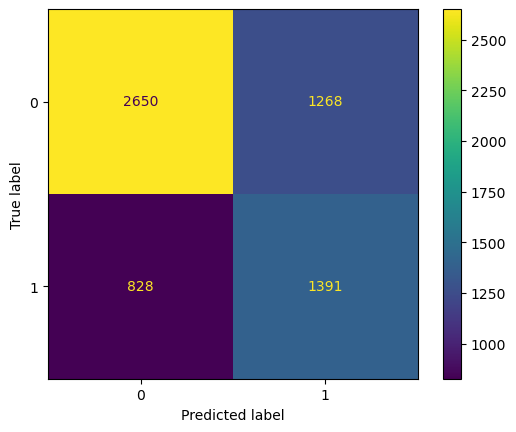

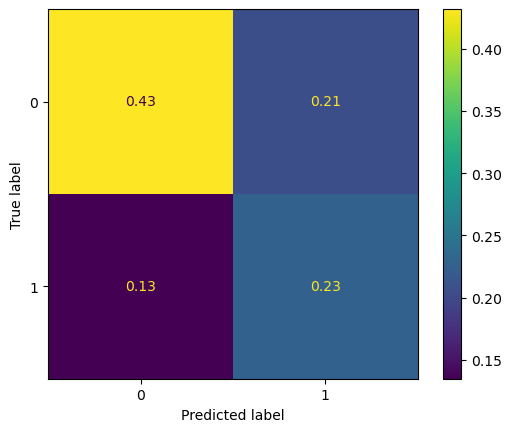

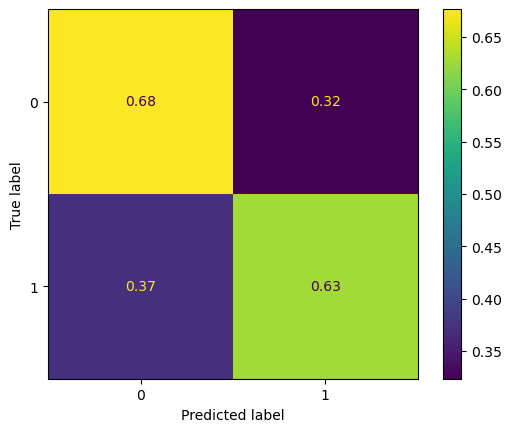

In [28]:
disp = ConfusionMatrixDisplay(cm_total)
disp.plot()
disp = ConfusionMatrixDisplay(cm_total_all)
disp.plot()
disp = ConfusionMatrixDisplay(cm_total_true)
disp.plot()